# Assignment 1: Smart Factory Predictive Maintenance — EDA
## IOT106TC Big Data Analytics

**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation — FD001 Subset  
**Objective:** Exploratory Data Analysis to understand sensor-based degradation patterns, calculate RUL, engineer features, and prepare data for Assignment 2 predictive modeling.

---

## Section 0: Setup and Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

PALETTE = sns.color_palette('Set2', 8)
LIFE_COLORS = {'early': '#2196F3', 'mid': '#FF9800', 'late': '#F44336'}

# Resolve project paths whether the kernel cwd is repo root or notebooks/
_cwd = Path.cwd().resolve()
_root = _cwd if (_cwd / 'data' / 'raw' / 'train_FD001.txt').exists() else _cwd.parent

RAW_DATA_PATH = str(_root / 'data' / 'raw' / 'train_FD001.txt')
PROCESSED_DIR = str(_root / 'data' / 'processed')
FIGURES_DIR   = str(_root / 'figures')
OUTPUTS_DIR   = str(_root / 'outputs')

for d in [PROCESSED_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(
        f'Raw data not found at: {RAW_DATA_PATH}\n'
        'Please download NASA C-MAPSS from the links in README.md '
        'and place train_FD001.txt in data/raw/'
    )

print('Setup complete. All directories verified.')
print(f'Raw data found: {RAW_DATA_PATH}')

Setup complete. All directories verified.
Raw data found: ../data/raw/train_FD001.txt


## Section 1: Data Loading

The FD001 training file has no header. It contains 26 whitespace-separated columns:
- `unit_number`: engine ID
- `time_in_cycles`: operational cycle index (1 = first recorded cycle)
- `operational_setting_1/2/3`: operational condition parameters
- `sensor_1` to `sensor_21`: IoT sensor channel readings

FD001 operates under a **single flight condition** (operational settings are approximately constant), which simplifies normalisation.

In [2]:
COLUMNS = [
    'unit_number', 'time_in_cycles',
    'operational_setting_1', 'operational_setting_2', 'operational_setting_3',
    'sensor_1',  'sensor_2',  'sensor_3',  'sensor_4',  'sensor_5',
    'sensor_6',  'sensor_7',  'sensor_8',  'sensor_9',  'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

df_raw = pd.read_csv(
    RAW_DATA_PATH,
    sep=r'\s+',
    header=None,
    names=COLUMNS,
    engine='python'
)

print(f'Loaded dataset shape : {df_raw.shape}')
print(f'Rows                 : {df_raw.shape[0]:,}')
print(f'Columns              : {df_raw.shape[1]}')
print(f'Unique engines       : {df_raw["unit_number"].nunique()}')
df_raw.head()

Loaded dataset shape : (20631, 26)
Rows                 : 20,631
Columns              : 26
Unique engines       : 100


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Section 2: Initial Data Exploration

In [3]:
# Data types and basic shape
print('=== Data Types ===')
print(df_raw.dtypes)
print()
print('=== Descriptive Statistics ===')
df_raw.describe().round(4)

=== Data Types ===
unit_number                int64
time_in_cycles             int64
operational_setting_1    float64
operational_setting_2    float64
operational_setting_3    float64
sensor_1                 float64
sensor_2                 float64
sensor_3                 float64
sensor_4                 float64
sensor_5                 float64
sensor_6                 float64
sensor_7                 float64
sensor_8                 float64
sensor_9                 float64
sensor_10                float64
sensor_11                float64
sensor_12                float64
sensor_13                float64
sensor_14                float64
sensor_15                float64
sensor_16                float64
sensor_17                  int64
sensor_18                  int64
sensor_19                float64
sensor_20                float64
sensor_21                float64
dtype: object

=== Descriptive Statistics ===


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.0000,20631.0000,20631.0000,20631.0000,20631.0,20631.00,20631.0000,20631.0000,20631.0000,20631.00,...,20631.0000,20631.0000,20631.0000,20631.0000,20631.00,20631.0000,20631.0,20631.0,20631.0000,20631.0000
mean,51.5066,108.8079,-0.0000,0.0000,100.0,518.67,642.6809,1590.5231,1408.9338,14.62,...,521.4135,2388.0962,8143.7527,8.4421,0.03,393.2107,2388.0,100.0,38.8163,23.2897
std,29.2276,68.8810,0.0022,0.0003,0.0,0.00,0.5001,6.1311,9.0006,0.00,...,0.7376,0.0719,19.0762,0.0375,0.00,1.5488,0.0,0.0,0.1807,0.1083
min,1.0000,1.0000,-0.0087,-0.0006,100.0,518.67,641.2100,1571.0400,1382.2500,14.62,...,518.6900,2387.8800,8099.9400,8.3249,0.03,388.0000,2388.0,100.0,38.1400,22.8942
25%,26.0000,52.0000,-0.0015,-0.0002,100.0,518.67,642.3250,1586.2600,1402.3600,14.62,...,520.9600,2388.0400,8133.2450,8.4149,0.03,392.0000,2388.0,100.0,38.7000,23.2218
50%,52.0000,104.0000,0.0000,0.0000,100.0,518.67,642.6400,1590.1000,1408.0400,14.62,...,521.4800,2388.0900,8140.5400,8.4389,0.03,393.0000,2388.0,100.0,38.8300,23.2979
75%,77.0000,156.0000,0.0015,0.0003,100.0,518.67,643.0000,1594.3800,1414.5550,14.62,...,521.9500,2388.1400,8148.3100,8.4656,0.03,394.0000,2388.0,100.0,38.9500,23.3668
max,100.0000,362.0000,0.0087,0.0006,100.0,518.67,644.5300,1616.9100,1441.4900,14.62,...,523.3800,2388.5600,8293.7200,8.5848,0.03,400.0000,2388.0,100.0,39.4300,23.6184


In [4]:
# Engine lifecycle statistics
engine_cycles = df_raw.groupby('unit_number')['time_in_cycles'].max()

print('=== Engine Lifetime (cycles) Statistics ===')
print(f'Number of engines : {len(engine_cycles)}')
print(f'Min lifetime      : {engine_cycles.min()}')
print(f'Max lifetime      : {engine_cycles.max()}')
print(f'Mean lifetime     : {engine_cycles.mean():.1f}')
print(f'Median lifetime   : {engine_cycles.median():.1f}')
print(f'Std deviation     : {engine_cycles.std():.1f}')

# Sanity check: cycles should start at 1 for each engine
min_cycle_per_engine = df_raw.groupby('unit_number')['time_in_cycles'].min()
print(f'\nAll engines start at cycle 1: {(min_cycle_per_engine == 1).all()}')

=== Engine Lifetime (cycles) Statistics ===
Number of engines : 100
Min lifetime      : 128
Max lifetime      : 362
Mean lifetime     : 206.3
Median lifetime   : 199.0
Std deviation     : 46.3

All engines start at cycle 1: True


## Section 3: Data Quality Assessment

In [5]:
# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(4)
print('=== Missing Values ===')
if missing.sum() == 0:
    print('No missing values found in any column.')
else:
    print(missing[missing > 0])

# Duplicate rows
n_duplicates = df_raw.duplicated().sum()
print(f'\n=== Duplicate Rows ===')
print(f'Exact duplicates found: {n_duplicates}')
if n_duplicates > 0:
    df_raw = df_raw.drop_duplicates()
    print(f'Duplicates removed. New shape: {df_raw.shape}')

# Data type validation
non_numeric = [col for col in df_raw.columns if not pd.api.types.is_numeric_dtype(df_raw[col])]
print(f'\n=== Non-numeric Columns ===')
if non_numeric:
    print(non_numeric)
else:
    print('All columns are numeric — no type conversion required.')

=== Missing Values ===
No missing values found in any column.

=== Duplicate Rows ===
Exact duplicates found: 0

=== Non-numeric Columns ===
All columns are numeric — no type conversion required.


In [6]:
# Constant / near-constant feature detection
SENSOR_COLS = [f'sensor_{i}' for i in range(1, 22)]
SETTING_COLS = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']

sensor_std = df_raw[SENSOR_COLS].std().sort_values()
low_var_threshold = 0.01
low_var_sensors = sensor_std[sensor_std < low_var_threshold].index.tolist()

print('=== Sensor Standard Deviations (ascending) ===')
print(sensor_std.round(6).to_string())
print(f'\nNear-constant sensors (std < {low_var_threshold}): {low_var_sensors}')
print('Note: near-constant sensors are NOT deleted — they are documented as low-information channels.')

=== Sensor Standard Deviations (ascending) ===
sensor_19     0.000000
sensor_18     0.000000
sensor_16     0.000000
sensor_10     0.000000
sensor_5      0.000000
sensor_1      0.000000
sensor_6      0.001389
sensor_15     0.037505
sensor_8      0.070985
sensor_13     0.071919
sensor_21     0.108251
sensor_20     0.180746
sensor_11     0.267087
sensor_2      0.500053
sensor_12     0.737553
sensor_7      0.885092
sensor_17     1.548763
sensor_3      6.131150
sensor_4      9.000605
sensor_14    19.076176
sensor_9     22.082880

Near-constant sensors (std < 0.01): ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6']
Note: near-constant sensors are NOT deleted — they are documented as low-information channels.


In [7]:
# Outlier screening (IQR method) — flag only, do not remove
outlier_counts = {}
for col in SENSOR_COLS:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    if n_out > 0:
        outlier_counts[col] = n_out

print('=== IQR Outlier Screening (3×IQR fence, flag only) ===')
if outlier_counts:
    for col, n in sorted(outlier_counts.items(), key=lambda x: -x[1]):
        pct = n / len(df_raw) * 100
        print(f'  {col}: {n:4d} rows ({pct:.2f}%)')
else:
    print('No extreme outliers detected beyond 3×IQR fence.')
print('\nOutlier handling policy: extreme late-life sensor values may represent valid')
print('degradation signals. No automatic removal applied.')

=== IQR Outlier Screening (3×IQR fence, flag only) ===
  sensor_9:  805 rows (3.90%)
  sensor_14:  689 rows (3.34%)
  sensor_6:  406 rows (1.97%)
  sensor_8:    6 rows (0.03%)
  sensor_13:    5 rows (0.02%)

Outlier handling policy: extreme late-life sensor values may represent valid
degradation signals. No automatic removal applied.


## Section 4: RUL Calculation and Feature Engineering

### RUL Definition
The FD001 dataset is a **run-to-failure** dataset. Each engine runs from an initial healthy state until failure. The last recorded cycle for each engine is its failure cycle. Therefore:

$$\text{RUL} = \text{max\_cycle}_{\text{engine}} - \text{time\_in\_cycles}$$

At the final cycle, RUL = 0 (engine has failed). At the first cycle, RUL = max_cycle − 1.

In [8]:
df = df_raw.copy()

# RUL calculation
max_cycle = df.groupby('unit_number')['time_in_cycles'].transform('max')
df['max_cycle']    = max_cycle
df['RUL']          = df['max_cycle'] - df['time_in_cycles']
df['cycle_ratio']  = df['time_in_cycles'] / df['max_cycle']

# Life stage (tertile-based, defensible split)
def assign_life_stage(cr):
    if cr <= 0.33:
        return 'early'
    elif cr <= 0.67:
        return 'mid'
    else:
        return 'late'

df['life_stage']  = df['cycle_ratio'].apply(assign_life_stage)
df['life_stage']  = pd.Categorical(df['life_stage'], categories=['early', 'mid', 'late'], ordered=True)

# Near-failure risk flag: RUL <= 30 cycles
df['near_failure'] = (df['RUL'] <= 30).astype(int)

# Capped RUL for Assignment 2 model stability
df['capped_RUL']  = df['RUL'].clip(upper=125)

print('=== RUL Sanity Checks ===')
# Confirm RUL reaches 0 at each engine's final cycle
final_cycles = df.groupby('unit_number').apply(lambda g: g.loc[g['time_in_cycles'].idxmax(), 'RUL'])
print(f'All engines reach RUL=0 at final cycle: {(final_cycles == 0).all()}')
print(f'\nRUL range: {df["RUL"].min()} – {df["RUL"].max()}')
print(f'Mean RUL : {df["RUL"].mean():.1f}')
print(f'Near-failure rows (RUL<=30): {df["near_failure"].sum():,} ({df["near_failure"].mean()*100:.1f}%)')
print()
print('Life stage distribution:')
print(df['life_stage'].value_counts().sort_index())

=== RUL Sanity Checks ===
All engines reach RUL=0 at final cycle: True

RUL range: 0 – 361
Mean RUL : 107.8
Near-failure rows (RUL<=30): 3,100 (15.0%)

Life stage distribution:
life_stage
early    6767
mid      6999
late     6865
Name: count, dtype: int64


In [9]:
# Rolling features: 20-cycle rolling mean for each sensor, per engine
ROLL_WINDOW = 20

# Compute sensor-RUL correlations first to select top sensors for rolling features
rul_corr = df[SENSOR_COLS].corrwith(df['RUL']).abs().sort_values(ascending=False)
top_sensors = rul_corr.head(10).index.tolist()

print(f'Top 10 sensors by |correlation with RUL|:')
print(rul_corr.head(10).round(4))

# Rolling mean per engine
df_sorted = df.sort_values(['unit_number', 'time_in_cycles'])
for sensor in top_sensors:
    col_name = f'{sensor}_roll{ROLL_WINDOW}'
    df_sorted[col_name] = (
        df_sorted.groupby('unit_number')[sensor]
        .transform(lambda x: x.rolling(window=ROLL_WINDOW, min_periods=1).mean())
    )

df = df_sorted.reset_index(drop=True)
roll_cols = [f'{s}_roll{ROLL_WINDOW}' for s in top_sensors]
print(f'\nRolling mean features created for: {top_sensors}')

Top 10 sensors by |correlation with RUL|:


sensor_11    0.6962
sensor_4     0.6789
sensor_12    0.6720
sensor_7     0.6572
sensor_15    0.6427
sensor_21    0.6357
sensor_20    0.6294
sensor_2     0.6065
sensor_17    0.6062
sensor_3     0.5845
dtype: float64



Rolling mean features created for: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2', 'sensor_17', 'sensor_3']

## Section 5: Figure 1 — Data Quality Summary

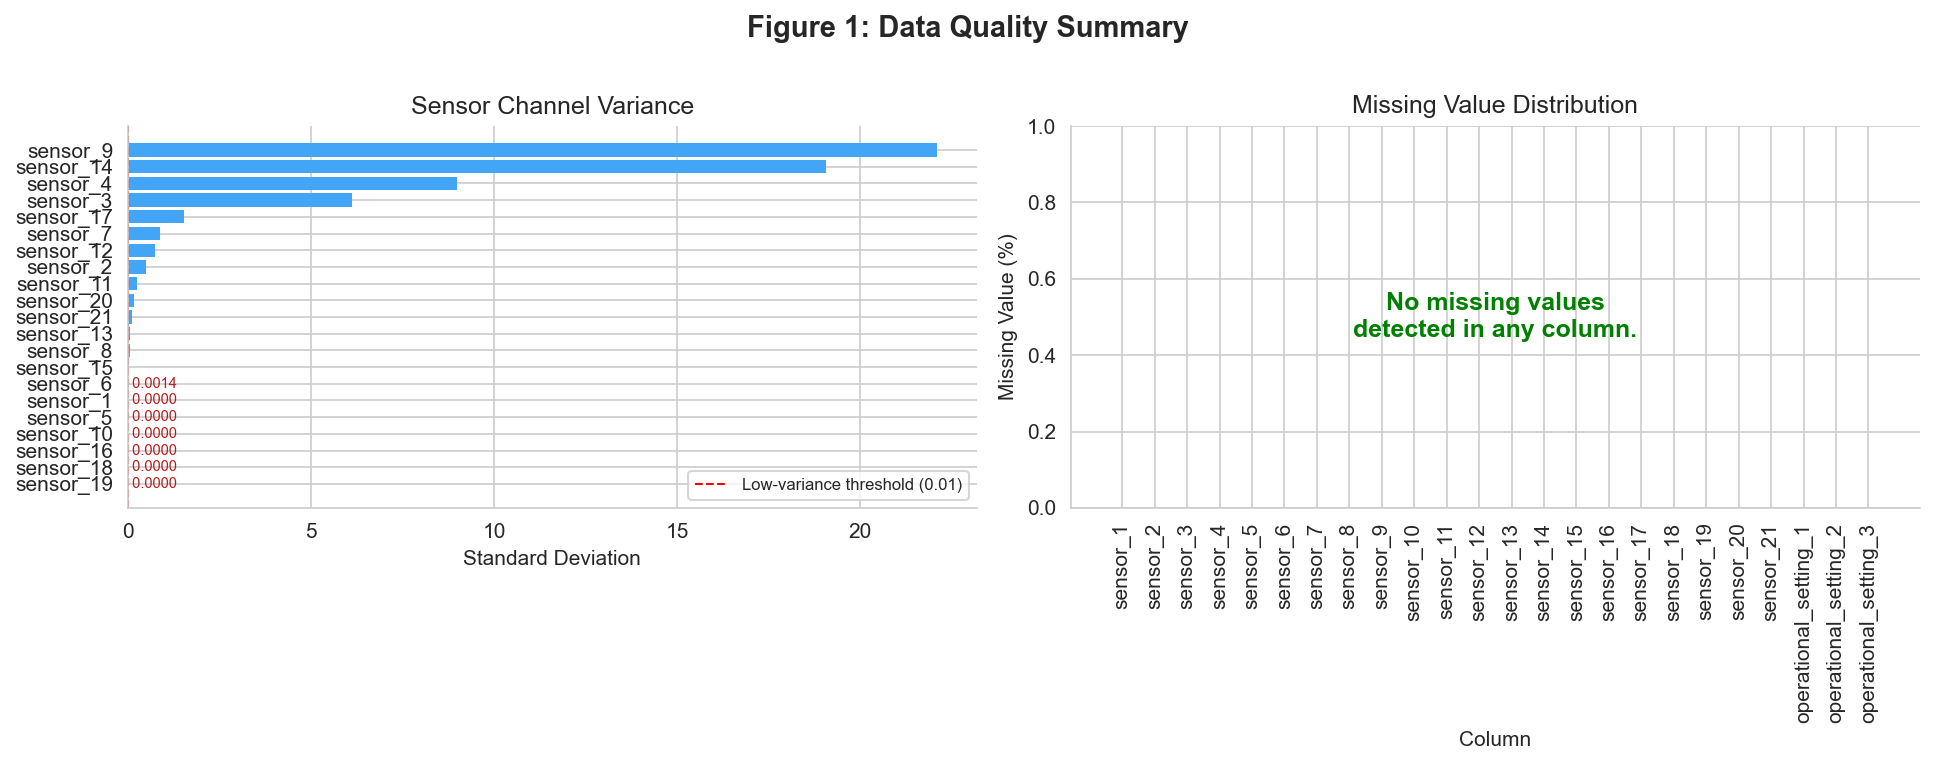

Saved: ../figures\Figure_01_data_quality_missingness.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1: Data Quality Summary', fontsize=14, fontweight='bold', y=1.01)

# Left: Sensor standard deviation (identifies low-variance / constant channels)
ax = axes[0]
colors_std = ['#EF5350' if v < low_var_threshold else '#42A5F5' for v in sensor_std.values]
bars = ax.barh(sensor_std.index, sensor_std.values, color=colors_std, edgecolor='none')
ax.axvline(low_var_threshold, color='red', linestyle='--', linewidth=1, label=f'Low-variance threshold ({low_var_threshold})')
ax.set_xlabel('Standard Deviation')
ax.set_title('Sensor Channel Variance')
ax.legend(fontsize=8)
# Annotate low-variance sensors
for i, (val, label) in enumerate(zip(sensor_std.values, sensor_std.index)):
    if val < low_var_threshold:
        ax.text(val + 0.001, i, f' {val:.4f}', va='center', fontsize=7, color='#B71C1C')

# Right: Missing values per column (expected: all zero for FD001)
ax2 = axes[1]
miss_df = pd.DataFrame({'column': SENSOR_COLS + SETTING_COLS, 'missing_pct': 0.0})
miss_pct_vals = df_raw[SENSOR_COLS + SETTING_COLS].isnull().mean() * 100
miss_df = miss_pct_vals.reset_index()
miss_df.columns = ['column', 'missing_pct']

if miss_df['missing_pct'].sum() == 0:
    ax2.bar(miss_df['column'], miss_df['missing_pct'], color='#42A5F5', edgecolor='none')
    ax2.set_ylim(0, 1)
    ax2.text(0.5, 0.5, 'No missing values\ndetected in any column.',
             ha='center', va='center', transform=ax2.transAxes,
             fontsize=12, color='green', fontweight='bold')
else:
    ax2.bar(miss_df['column'], miss_df['missing_pct'], color='#EF5350', edgecolor='none')

ax2.set_xlabel('Column')
ax2.set_ylabel('Missing Value (%)')
ax2.set_title('Missing Value Distribution')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'Figure_01_data_quality_missingness.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

In [11]:
# Build and save data quality summary table
dq_summary = pd.DataFrame({
    'metric': [
        'Total rows (raw)',
        'Total rows (after deduplication)',
        'Columns',
        'Missing values (total)',
        'Duplicate rows removed',
        'Near-constant sensor channels (std < 0.01)',
        'Outlier rows flagged (3×IQR, any sensor)',
        'Engineered features added'
    ],
    'value': [
        df_raw.shape[0],
        df.shape[0],
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        n_duplicates,
        len(low_var_sensors),
        sum(outlier_counts.values()) if outlier_counts else 0,
        len(['RUL', 'max_cycle', 'cycle_ratio', 'life_stage', 'near_failure', 'capped_RUL'] + roll_cols)
    ]
})

dq_summary.to_csv(os.path.join(OUTPUTS_DIR, 'data_quality_summary.csv'), index=False)
print('Data quality summary saved.')
print(dq_summary.to_string(index=False))

Data quality summary saved.
                                    metric  value
                          Total rows (raw)  20631
          Total rows (after deduplication)  20631
                                   Columns     26
                    Missing values (total)      0
                    Duplicate rows removed      0
Near-constant sensor channels (std < 0.01)      7
  Outlier rows flagged (3×IQR, any sensor)   1911
                 Engineered features added     16


## Section 6: Figure 2 — Engine Lifetime Distribution

Life group thresholds: Short < 187 cycles, Medium 187–213, Long > 213
life_group
Short life     33
Medium life    35
Long life      32
Name: count, dtype: int64


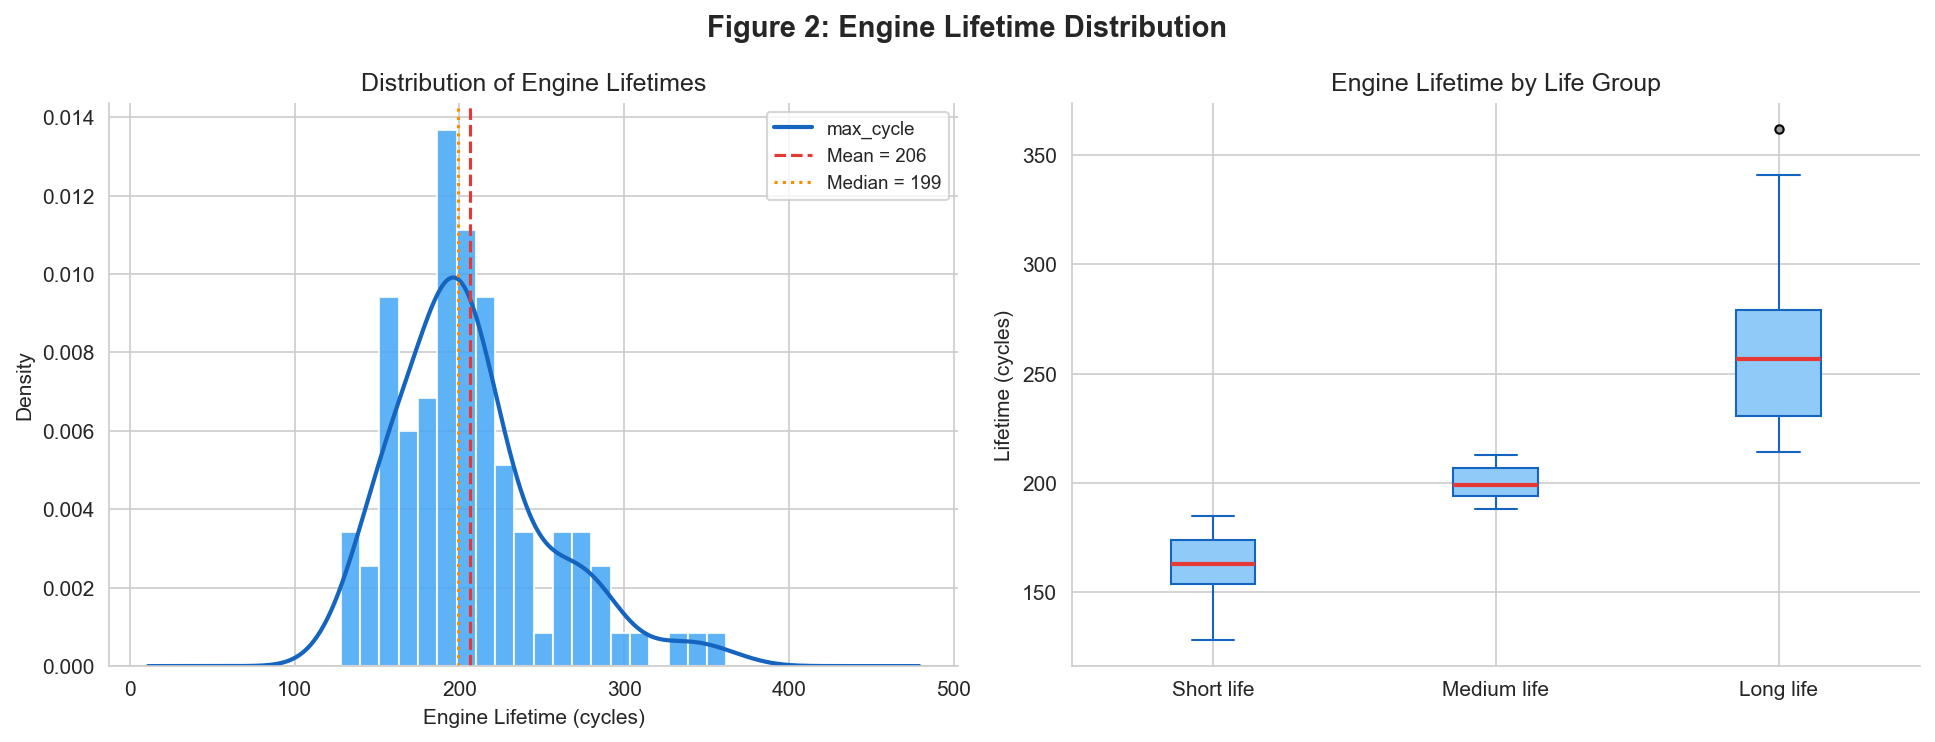

Saved: ../figures\Figure_02_engine_lifetime_distribution.png


In [12]:
engine_summary = df.groupby('unit_number').agg(
    max_cycle=('max_cycle', 'first'),
    near_failure_count=('near_failure', 'sum'),
    total_cycles=('time_in_cycles', 'count')
).reset_index()

# Classify engines as short, medium, long life using tertiles
q33 = engine_summary['max_cycle'].quantile(0.33)
q67 = engine_summary['max_cycle'].quantile(0.67)
engine_summary['life_group'] = pd.cut(
    engine_summary['max_cycle'],
    bins=[0, q33, q67, float('inf')],
    labels=['Short life', 'Medium life', 'Long life']
)

print(f'Life group thresholds: Short < {q33:.0f} cycles, Medium {q33:.0f}–{q67:.0f}, Long > {q67:.0f}')
print(engine_summary['life_group'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2: Engine Lifetime Distribution', fontsize=14, fontweight='bold')

# Left: Histogram with KDE
ax = axes[0]
ax.hist(engine_summary['max_cycle'], bins=20, color='#42A5F5', edgecolor='white', alpha=0.85, density=True)
engine_summary['max_cycle'].plot.kde(ax=ax, color='#1565C0', linewidth=2)
ax.axvline(engine_summary['max_cycle'].mean(), color='#E53935', linestyle='--', linewidth=1.5,
           label=f'Mean = {engine_summary["max_cycle"].mean():.0f}')
ax.axvline(engine_summary['max_cycle'].median(), color='#FB8C00', linestyle=':', linewidth=1.5,
           label=f'Median = {engine_summary["max_cycle"].median():.0f}')
ax.set_xlabel('Engine Lifetime (cycles)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Engine Lifetimes')
ax.legend()

# Right: Boxplot by life group
ax2 = axes[1]
group_order = ['Short life', 'Medium life', 'Long life']
group_data = [engine_summary.loc[engine_summary['life_group'] == g, 'max_cycle'].values for g in group_order]
bp = ax2.boxplot(group_data, labels=group_order, patch_artist=True,
                 boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                 medianprops=dict(color='#E53935', linewidth=2),
                 whiskerprops=dict(color='#1565C0'),
                 capprops=dict(color='#1565C0'),
                 flierprops=dict(marker='o', markerfacecolor='#9E9E9E', markersize=4))
ax2.set_ylabel('Lifetime (cycles)')
ax2.set_title('Engine Lifetime by Life Group')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'Figure_02_engine_lifetime_distribution.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 7: Figure 3 — RUL Distribution

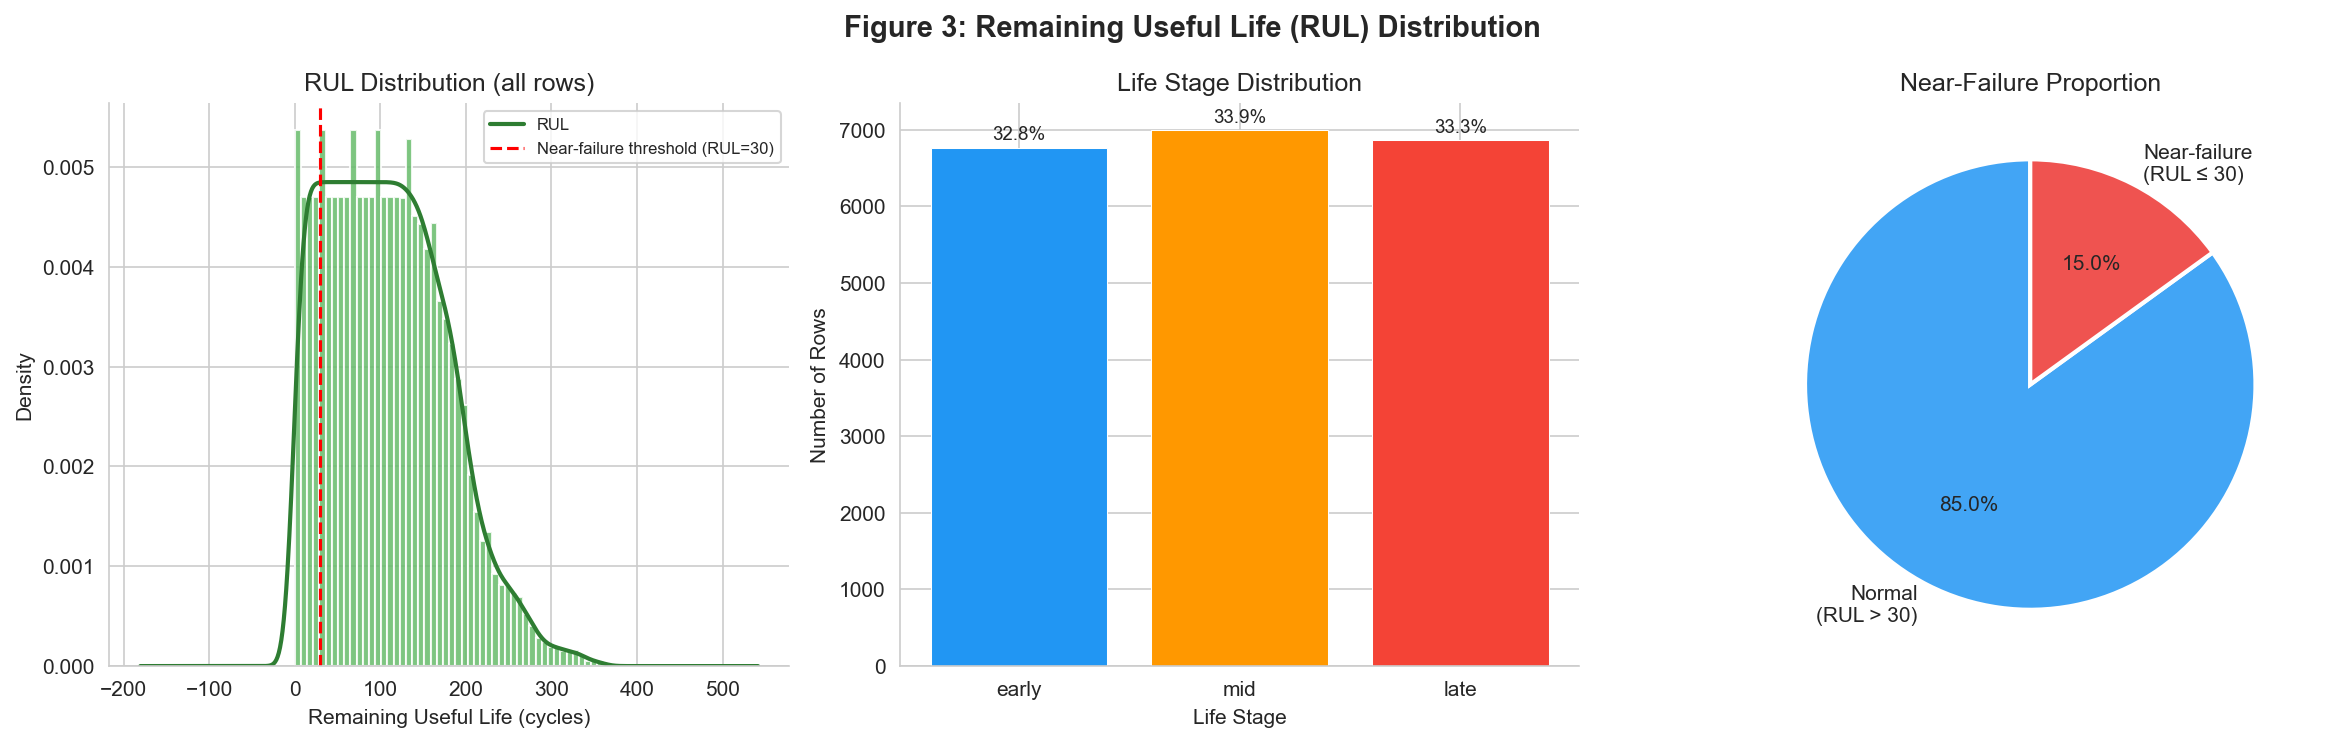

Saved: ../figures\Figure_03_rul_distribution.png
Near-failure rows: 3,100 / 20,631 = 15.0%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 3: Remaining Useful Life (RUL) Distribution', fontsize=14, fontweight='bold')

# Left: RUL histogram
ax = axes[0]
ax.hist(df['RUL'], bins=50, color='#66BB6A', edgecolor='white', alpha=0.85, density=True)
df['RUL'].plot.kde(ax=ax, color='#2E7D32', linewidth=2)
ax.axvline(30, color='red', linestyle='--', linewidth=1.5, label='Near-failure threshold (RUL=30)')
ax.set_xlabel('Remaining Useful Life (cycles)')
ax.set_ylabel('Density')
ax.set_title('RUL Distribution (all rows)')
ax.legend(fontsize=8)

# Middle: Life stage distribution (pie or bar)
ax2 = axes[1]
stage_counts = df['life_stage'].value_counts().sort_index()
stage_colors = [LIFE_COLORS[s] for s in stage_counts.index]
bars = ax2.bar(stage_counts.index, stage_counts.values, color=stage_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, stage_counts.values):
    pct = val / len(df) * 100
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f'{pct:.1f}%', ha='center', fontsize=9)
ax2.set_xlabel('Life Stage')
ax2.set_ylabel('Number of Rows')
ax2.set_title('Life Stage Distribution')

# Right: Near-failure proportion
ax3 = axes[2]
nf_counts = df['near_failure'].value_counts().sort_index()
labels = ['Normal\n(RUL > 30)', 'Near-failure\n(RUL ≤ 30)']
ax3.pie(nf_counts.values, labels=labels, colors=['#42A5F5', '#EF5350'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax3.set_title('Near-Failure Proportion')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'Figure_03_rul_distribution.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')
print(f'Near-failure rows: {df["near_failure"].sum():,} / {len(df):,} = {df["near_failure"].mean()*100:.1f}%')

## Section 8: Figure 4 — Engine Lifecycle Examples (8+ Engines)

Selected engines for lifecycle plot: [39, 91, 87, 3, 25, 59, 69, 92]


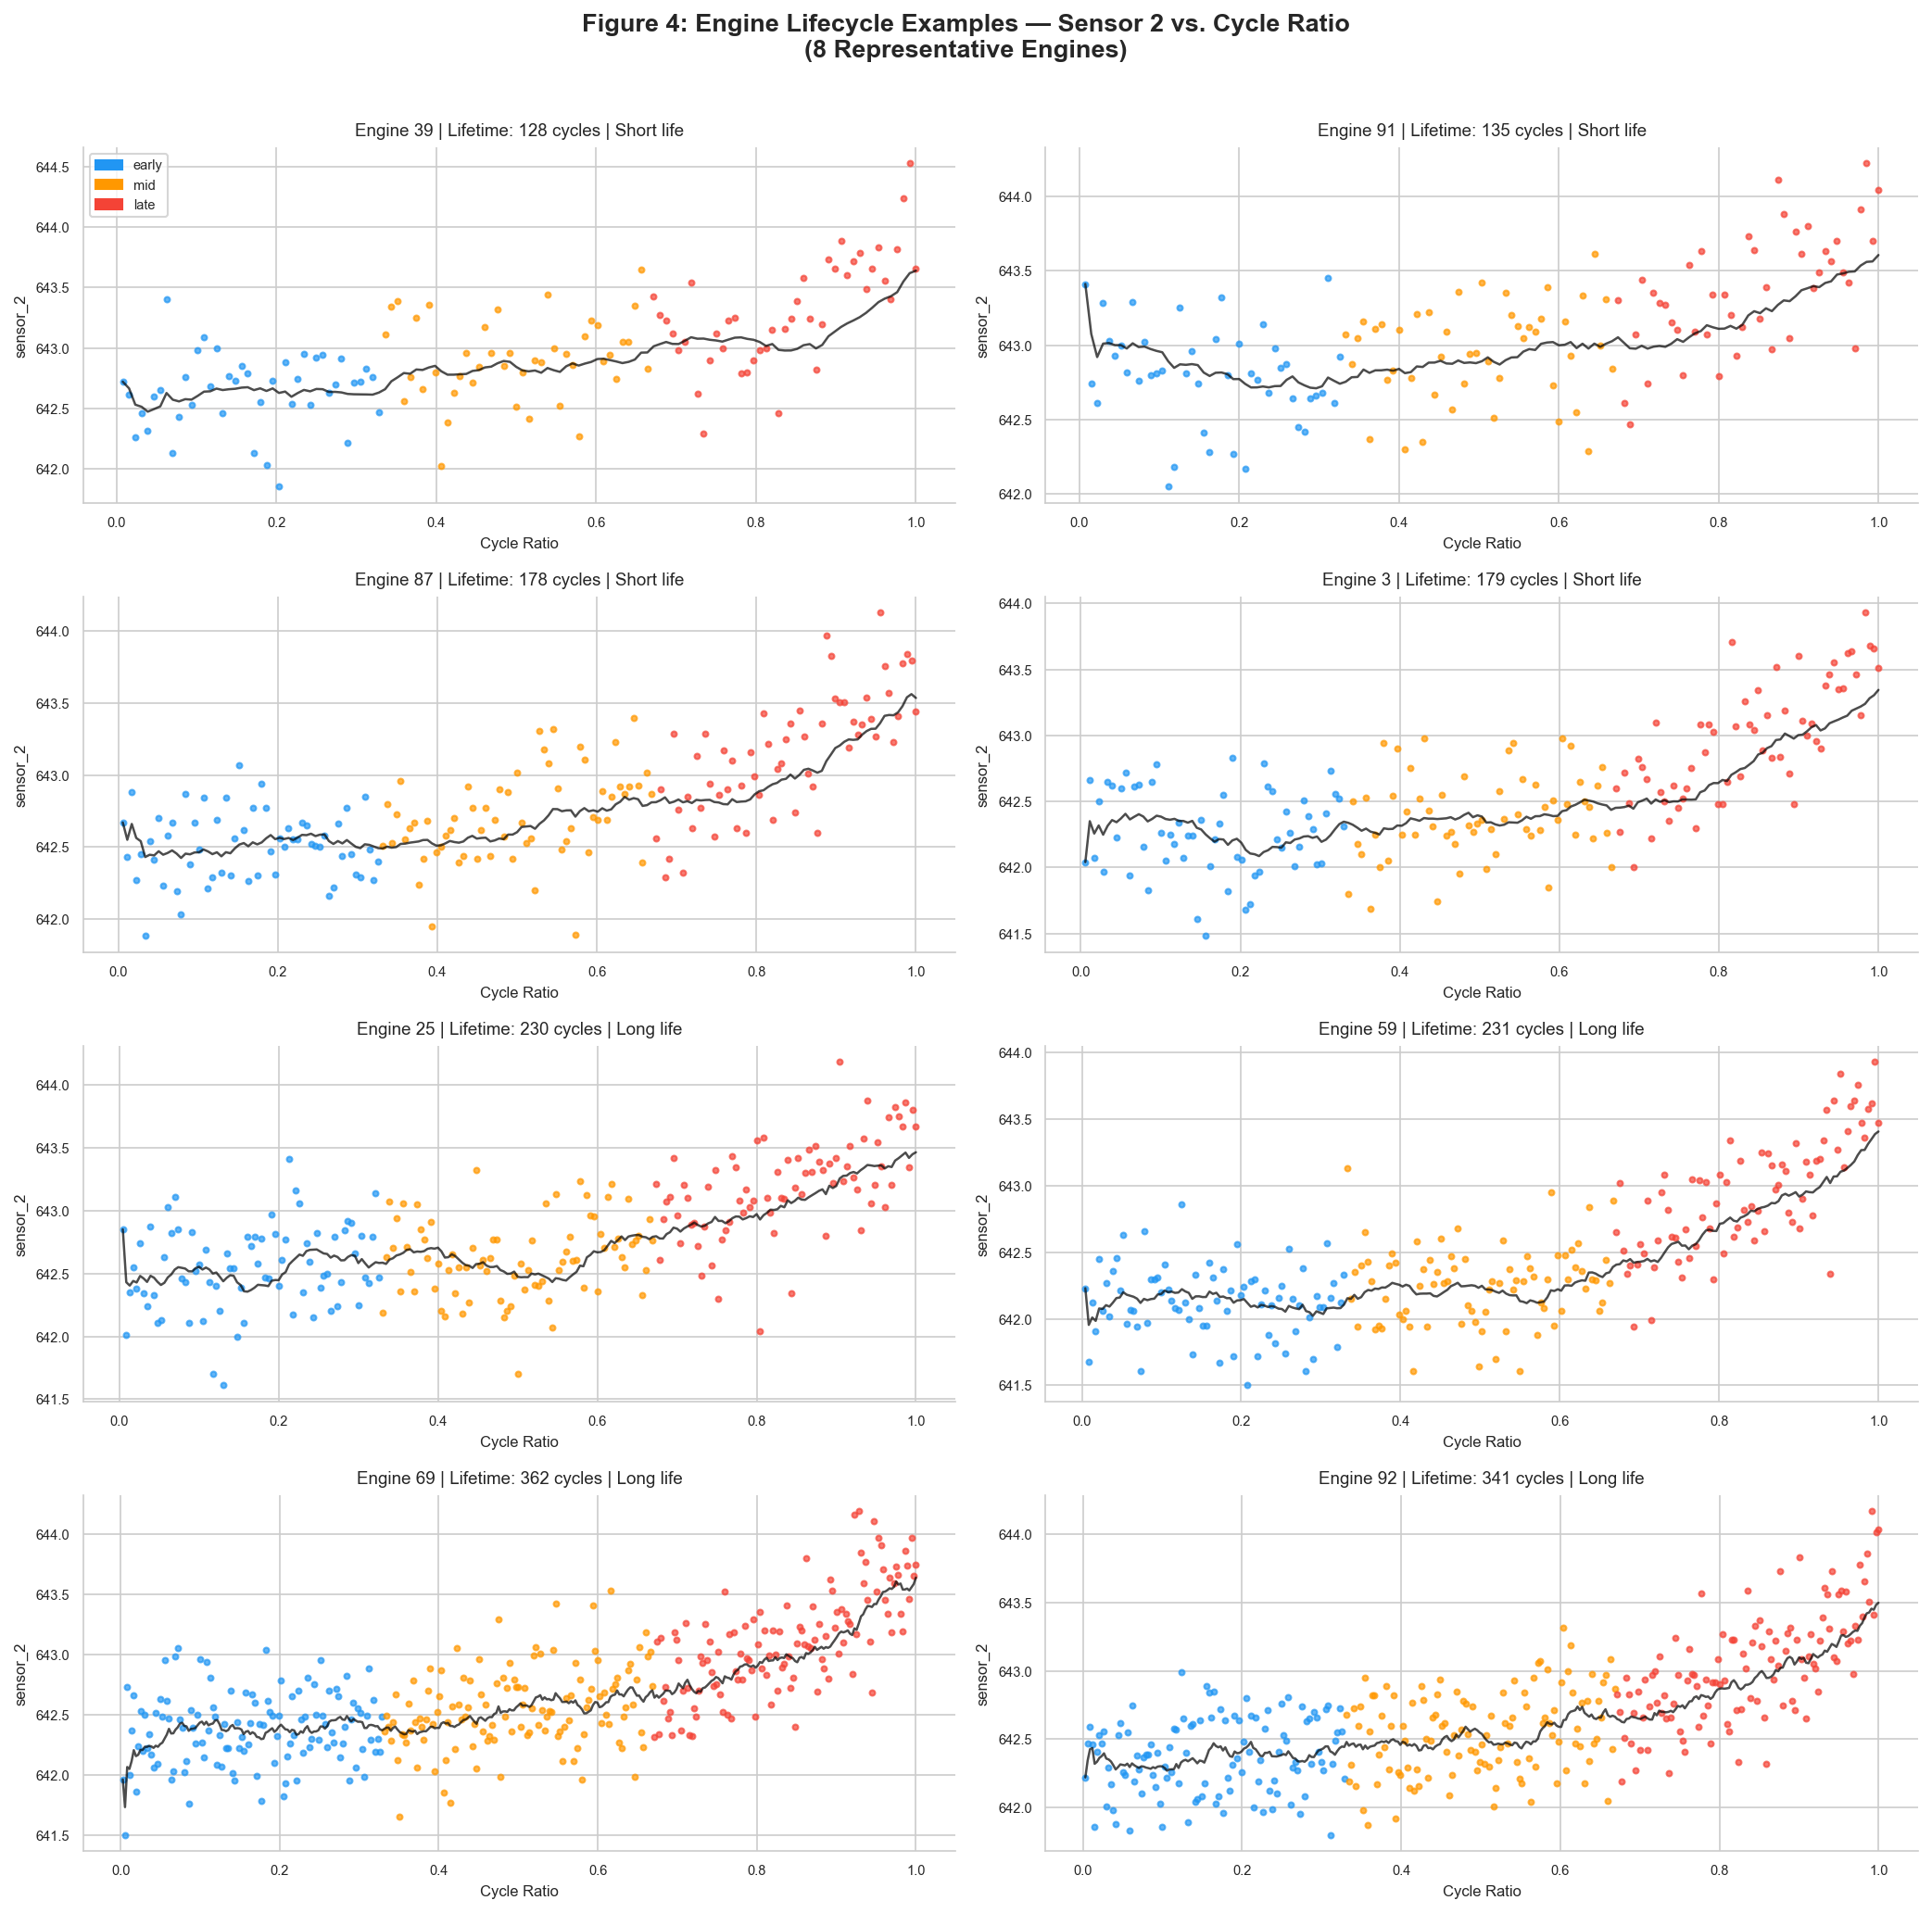

Saved: ../figures\Figure_04_engine_lifecycle_examples.png


In [14]:
# Select 8 representative engines: 2 short, 2 medium-short, 2 medium-long, 2 long
short_engines  = engine_summary.nsmallest(2, 'max_cycle')['unit_number'].tolist()
long_engines   = engine_summary.nlargest(2, 'max_cycle')['unit_number'].tolist()
sorted_eng     = engine_summary.sort_values('max_cycle')['unit_number'].tolist()
n = len(sorted_eng)
mid_lo_engines = [sorted_eng[n // 4], sorted_eng[n // 4 + 1]]
mid_hi_engines = [sorted_eng[3 * n // 4], sorted_eng[3 * n // 4 + 1]]
selected_engines = short_engines + mid_lo_engines + mid_hi_engines + long_engines

print(f'Selected engines for lifecycle plot: {selected_engines}')

# Use sensor_2 as the representative sensor (typically highly informative)
DEMO_SENSOR = 'sensor_2'

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle('Figure 4: Engine Lifecycle Examples — Sensor 2 vs. Cycle Ratio\n(8 Representative Engines)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for idx, eng_id in enumerate(selected_engines):
    ax = axes[idx]
    eng_data = df[df['unit_number'] == eng_id].sort_values('time_in_cycles')
    life = engine_summary.loc[engine_summary['unit_number'] == eng_id, 'max_cycle'].values[0]
    group = engine_summary.loc[engine_summary['unit_number'] == eng_id, 'life_group'].values[0]

    # Color points by life stage
    for stage, color in LIFE_COLORS.items():
        mask = eng_data['life_stage'] == stage
        ax.scatter(eng_data.loc[mask, 'cycle_ratio'], eng_data.loc[mask, DEMO_SENSOR],
                   c=color, s=8, alpha=0.7, label=stage)

    # Rolling mean overlay
    roll_col = f'{DEMO_SENSOR}_roll{ROLL_WINDOW}'
    if roll_col in eng_data.columns:
        ax.plot(eng_data['cycle_ratio'], eng_data[roll_col], color='black', linewidth=1.2, alpha=0.7)

    ax.set_xlabel('Cycle Ratio', fontsize=8)
    ax.set_ylabel(DEMO_SENSOR, fontsize=8)
    ax.set_title(f'Engine {eng_id} | Lifetime: {life} cycles | {group}', fontsize=9)
    ax.tick_params(labelsize=7)

    if idx == 0:
        handles = [mpatches.Patch(color=c, label=l) for l, c in LIFE_COLORS.items()]
        ax.legend(handles=handles, fontsize=7, loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig_path = os.path.join(FIGURES_DIR, 'Figure_04_engine_lifecycle_examples.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 9: Sensor Screening — Variance and RUL Correlation

In [15]:
# Full sensor screening table
rul_corr_signed = df[SENSOR_COLS].corrwith(df['RUL'])
rul_corr_abs    = rul_corr_signed.abs()
sensor_var      = df[SENSOR_COLS].var()

sensor_screen = pd.DataFrame({
    'sensor': SENSOR_COLS,
    'std': df[SENSOR_COLS].std().values,
    'variance': sensor_var.values,
    'corr_with_RUL': rul_corr_signed.values,
    'abs_corr_with_RUL': rul_corr_abs.values,
    'low_variance': [s in low_var_sensors for s in SENSOR_COLS]
}).sort_values('abs_corr_with_RUL', ascending=False).reset_index(drop=True)

sensor_screen.to_csv(os.path.join(OUTPUTS_DIR, 'sensor_rul_correlation.csv'), index=False)
print('=== Sensor Screening Results (sorted by |corr with RUL|) ===')
print(sensor_screen[['sensor', 'std', 'corr_with_RUL', 'abs_corr_with_RUL', 'low_variance']].to_string(index=False))

=== Sensor Screening Results (sorted by |corr with RUL|) ===
   sensor          std  corr_with_RUL  abs_corr_with_RUL  low_variance
sensor_11 2.670874e-01  -6.962281e-01       6.962281e-01         False
 sensor_4 9.000605e+00  -6.789482e-01       6.789482e-01         False
sensor_12 7.375534e-01   6.719831e-01       6.719831e-01         False
 sensor_7 8.850923e-01   6.572227e-01       6.572227e-01         False
sensor_15 3.750504e-02  -6.426670e-01       6.426670e-01         False
sensor_21 1.082509e-01   6.356620e-01       6.356620e-01         False
sensor_20 1.807464e-01   6.294285e-01       6.294285e-01         False
 sensor_2 5.000533e-01  -6.064840e-01       6.064840e-01         False
sensor_17 1.548763e+00  -6.061536e-01       6.061536e-01         False
 sensor_3 6.131150e+00  -5.845204e-01       5.845204e-01         False
 sensor_8 7.098548e-02  -5.639684e-01       5.639684e-01         False
sensor_13 7.191892e-02  -5.625688e-01       5.625688e-01         False
 sensor_9 2.2082

## Section 10: Figure 5 — Sensor-RUL Correlation Ranking

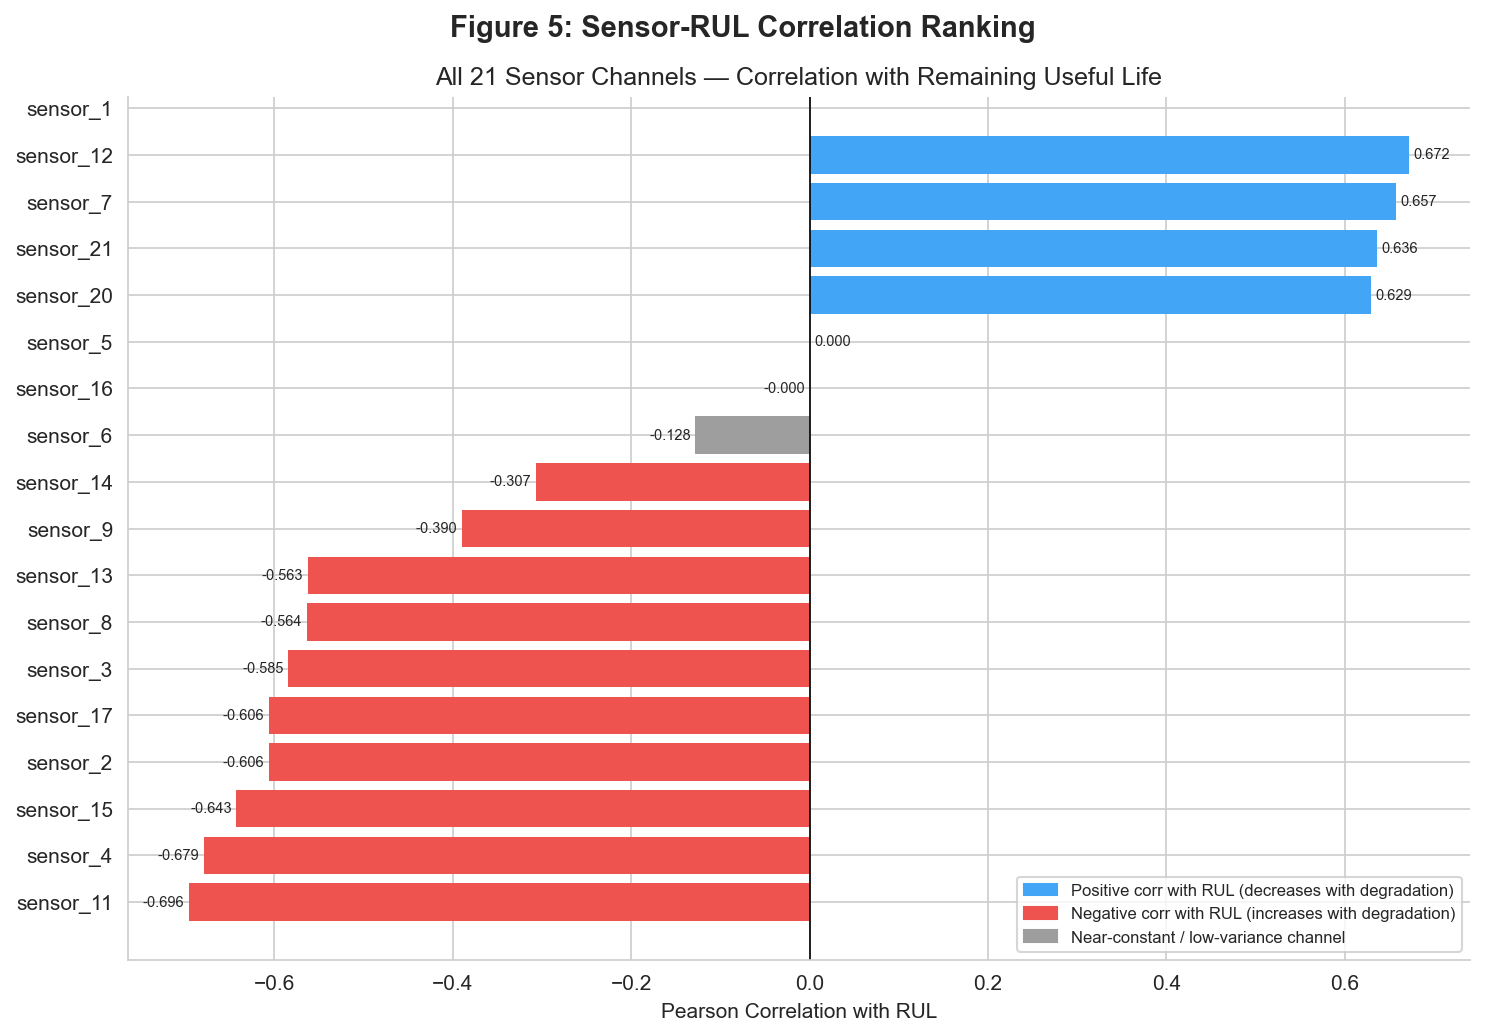

Saved: ../figures\Figure_05_sensor_rul_correlation.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Figure 5: Sensor-RUL Correlation Ranking', fontsize=14, fontweight='bold')

sorted_corr = sensor_screen.sort_values('corr_with_RUL')
bar_colors = ['#EF5350' if c < 0 else '#42A5F5' for c in sorted_corr['corr_with_RUL']]
# Highlight low-variance sensors
bar_colors = ['#9E9E9E' if lv else c for c, lv in zip(bar_colors, sorted_corr['low_variance'])]

bars = ax.barh(sorted_corr['sensor'], sorted_corr['corr_with_RUL'], color=bar_colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)

legend_handles = [
    mpatches.Patch(color='#42A5F5', label='Positive corr with RUL (decreases with degradation)'),
    mpatches.Patch(color='#EF5350', label='Negative corr with RUL (increases with degradation)'),
    mpatches.Patch(color='#9E9E9E', label='Near-constant / low-variance channel'),
]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')
ax.set_xlabel('Pearson Correlation with RUL')
ax.set_title('All 21 Sensor Channels — Correlation with Remaining Useful Life')

# Annotate values
for bar, val in zip(bars, sorted_corr['corr_with_RUL']):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2, f'{val:.3f}',
            va='center', ha=ha, fontsize=7)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'Figure_05_sensor_rul_correlation.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 11: Figure 6 — Key Sensor Trends Over Cycle Ratio

Key sensors for trend plots: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21']


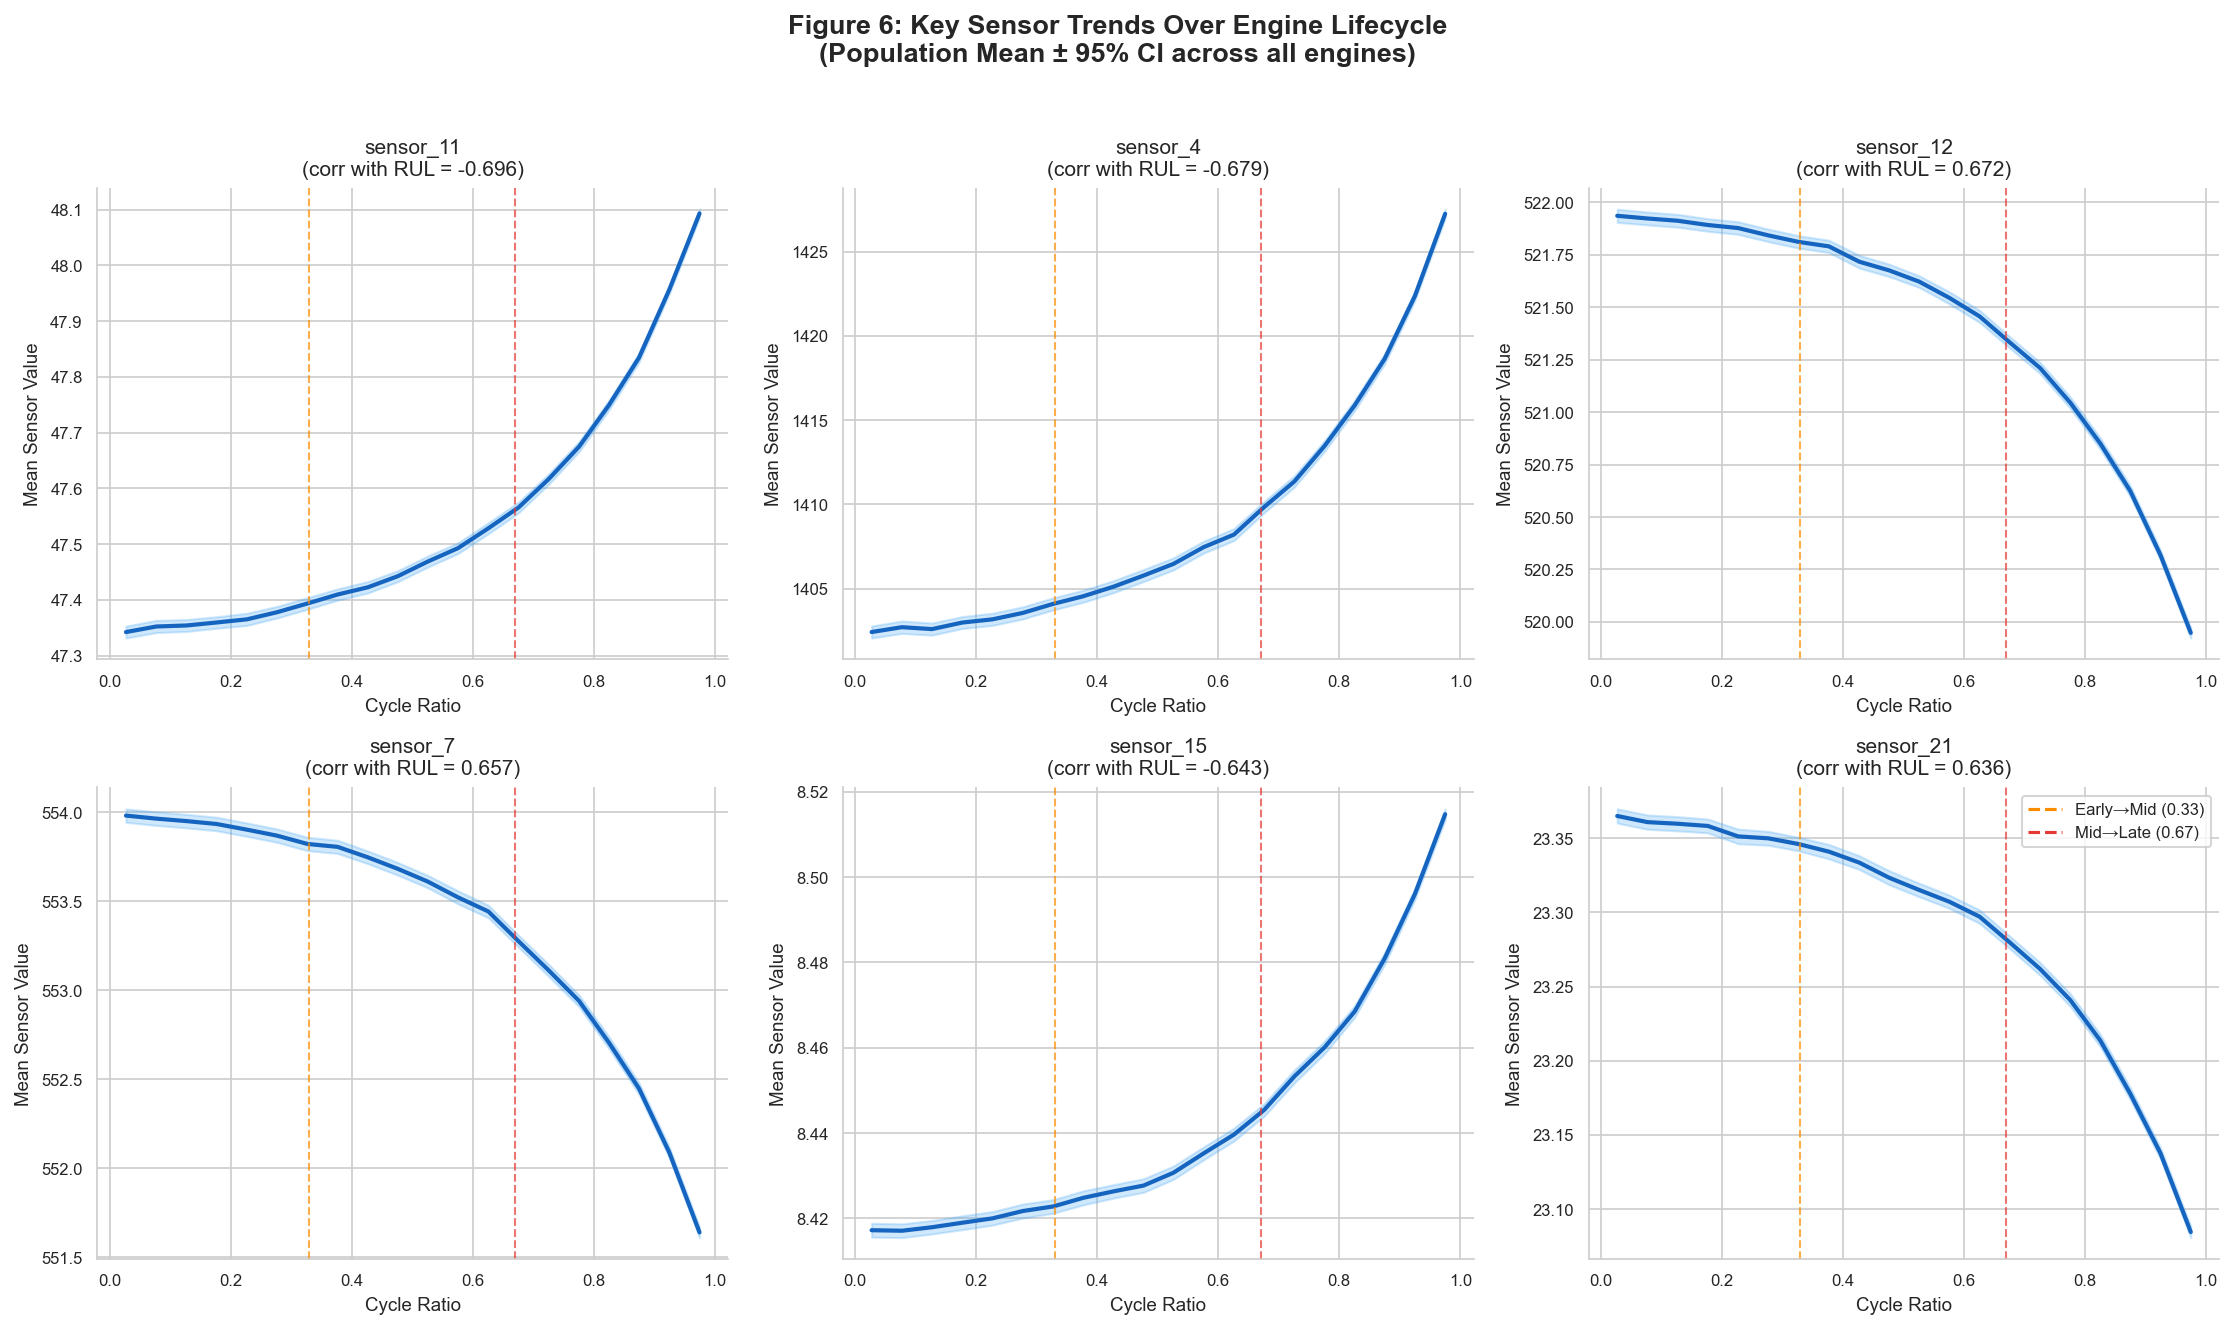

Saved: ../figures\Figure_06_key_sensor_trends.png


In [17]:
# Select top 6 informative sensors (highest |corr with RUL|, excluding near-constant)
informative_sensors = sensor_screen[~sensor_screen['low_variance']]['sensor'].head(6).tolist()
print(f'Key sensors for trend plots: {informative_sensors}')

# Bin cycle_ratio into 20 bins and compute mean sensor value per bin
df['cr_bin'] = pd.cut(df['cycle_ratio'], bins=20)
cr_bin_means = df.groupby('cr_bin', observed=True)[informative_sensors].mean()
cr_bin_centers = [interval.mid for interval in cr_bin_means.index]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Figure 6: Key Sensor Trends Over Engine Lifecycle\n(Population Mean ± 95% CI across all engines)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for idx, sensor in enumerate(informative_sensors):
    ax = axes[idx]

    # Per-bin mean and 95% CI
    bin_stats = df.groupby('cr_bin', observed=True)[sensor].agg(['mean', 'std', 'count'])
    bin_stats['se'] = bin_stats['std'] / np.sqrt(bin_stats['count'])
    bin_stats['ci95'] = 1.96 * bin_stats['se']
    xvals = [iv.mid for iv in bin_stats.index]

    ax.plot(xvals, bin_stats['mean'], color='#1565C0', linewidth=2)
    ax.fill_between(xvals,
                    bin_stats['mean'] - bin_stats['ci95'],
                    bin_stats['mean'] + bin_stats['ci95'],
                    alpha=0.25, color='#42A5F5')

    # Life stage dividers
    ax.axvline(0.33, color='#FB8C00', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(0.67, color='#E53935', linestyle='--', linewidth=1, alpha=0.7)

    corr_val = sensor_screen.loc[sensor_screen['sensor'] == sensor, 'corr_with_RUL'].values[0]
    ax.set_xlabel('Cycle Ratio', fontsize=9)
    ax.set_ylabel('Mean Sensor Value', fontsize=9)
    ax.set_title(f'{sensor}\n(corr with RUL = {corr_val:.3f})', fontsize=10)
    ax.tick_params(labelsize=8)

# Add legend on last subplot
import matplotlib.lines as mlines
early_line = mlines.Line2D([], [], color='#FB8C00', linestyle='--', label='Early→Mid (0.33)')
mid_line   = mlines.Line2D([], [], color='#E53935', linestyle='--', label='Mid→Late (0.67)')
axes[-1].legend(handles=[early_line, mid_line], fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig_path = os.path.join(FIGURES_DIR, 'Figure_06_key_sensor_trends.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 12: Figure 7 — Life-Stage Sensor Boxplots

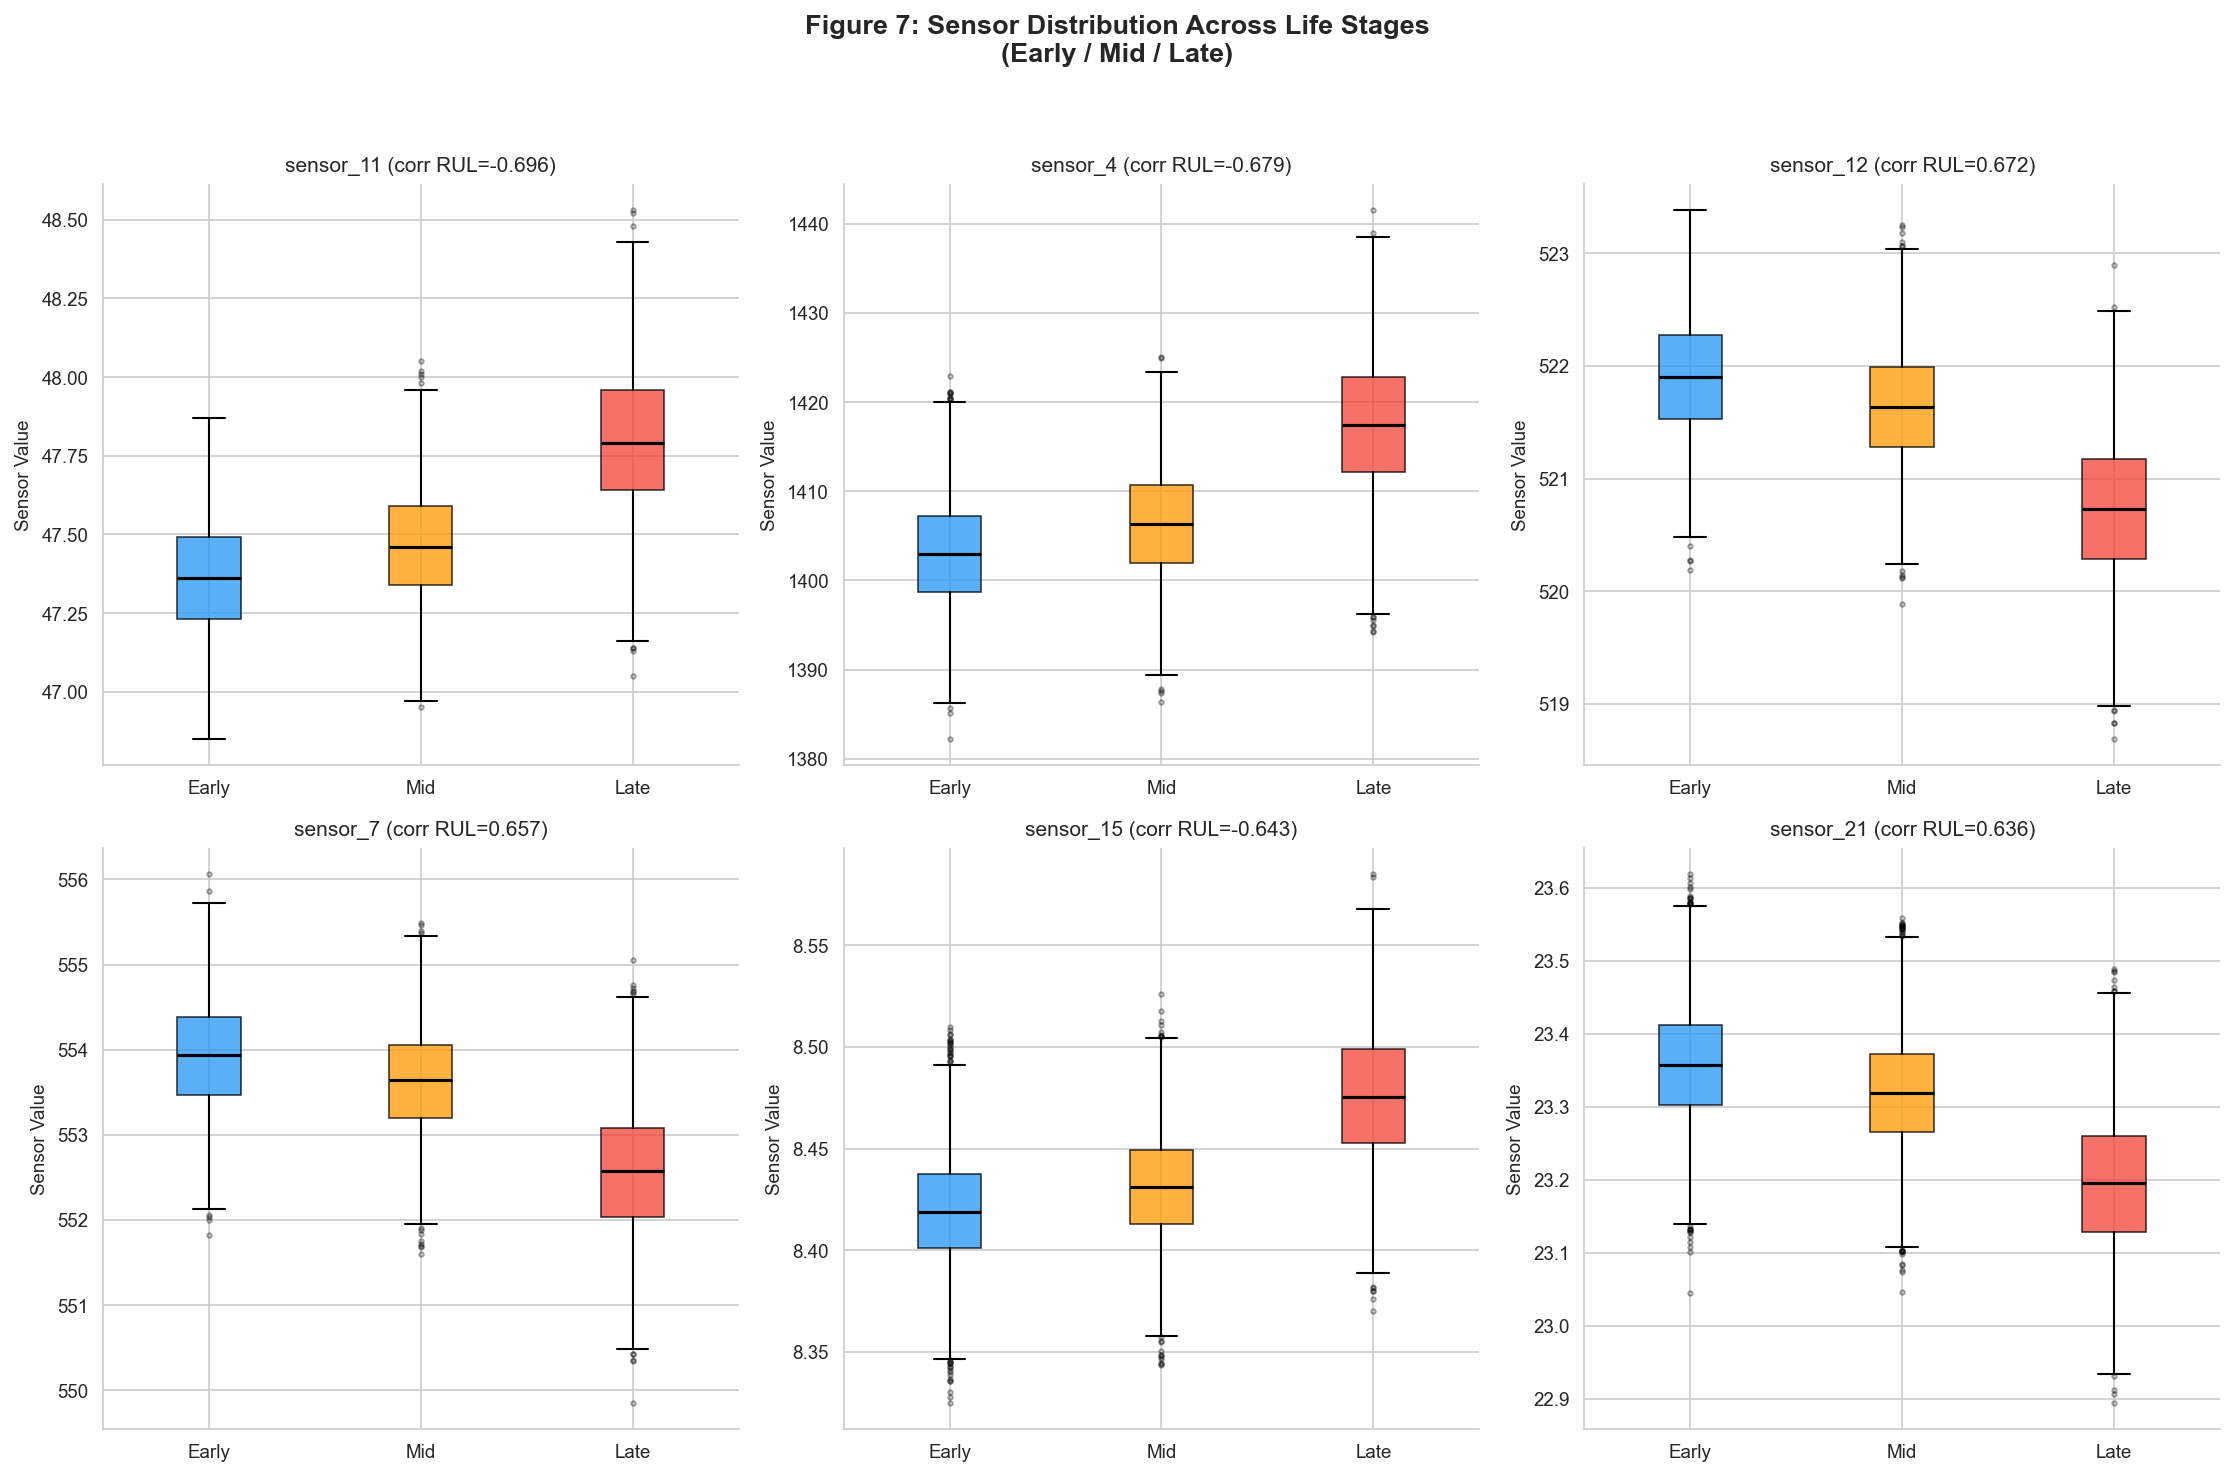

Saved: ../figures\Figure_07_life_stage_sensor_boxplots.png
Life-stage shift table saved.
   sensor  mean_early  mean_late  shift_early_to_late
 sensor_1    518.6700   518.6700               0.0000
 sensor_2    642.3914   643.1035               0.7122
 sensor_3   1587.0648  1595.5771               8.5123
 sensor_4   1402.9933  1417.4641              14.4708
 sensor_5     14.6200    14.6200              -0.0000
 sensor_6     21.6096    21.6100               0.0004
 sensor_7    553.9234   552.5533              -1.3700
 sensor_8   2388.0593  2388.1507               0.0913
 sensor_9   9056.5407  9078.6341              22.0934
sensor_10      1.3000     1.3000               0.0000
sensor_11     47.3611    47.7994               0.4383
sensor_12    521.8915   520.7226              -1.1689
sensor_13   2388.0583  2388.1507               0.0925
sensor_14   8137.7590  8153.1537              15.3947
sensor_15      8.4192     8.4762               0.0570
sensor_16      0.0300     0.0300               

In [18]:
# Use top 6 informative sensors
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Figure 7: Sensor Distribution Across Life Stages\n(Early / Mid / Late)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for idx, sensor in enumerate(informative_sensors):
    ax = axes[idx]
    data_by_stage = [df.loc[df['life_stage'] == stage, sensor].values for stage in ['early', 'mid', 'late']]
    bp = ax.boxplot(data_by_stage, labels=['Early', 'Mid', 'Late'],
                    patch_artist=True,
                    boxprops=dict(linewidth=0.8),
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4))

    stage_colors_list = [LIFE_COLORS['early'], LIFE_COLORS['mid'], LIFE_COLORS['late']]
    for patch, color in zip(bp['boxes'], stage_colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    corr_val = sensor_screen.loc[sensor_screen['sensor'] == sensor, 'corr_with_RUL'].values[0]
    ax.set_ylabel('Sensor Value', fontsize=9)
    ax.set_title(f'{sensor} (corr RUL={corr_val:.3f})', fontsize=10)
    ax.tick_params(labelsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = os.path.join(FIGURES_DIR, 'Figure_07_life_stage_sensor_boxplots.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

# Compute and save life-stage shift table
stage_shift = df.groupby('life_stage', observed=False)[SENSOR_COLS].mean().T
stage_shift.columns = ['mean_early', 'mean_mid', 'mean_late']
stage_shift['shift_early_to_late'] = stage_shift['mean_late'] - stage_shift['mean_early']
stage_shift['pct_shift'] = (stage_shift['shift_early_to_late'] / stage_shift['mean_early'].abs().replace(0, np.nan) * 100)
stage_shift = stage_shift.reset_index().rename(columns={'index': 'sensor'})
stage_shift.to_csv(os.path.join(OUTPUTS_DIR, 'sensor_life_stage_shift.csv'), index=False)
print('Life-stage shift table saved.')
print(stage_shift[['sensor', 'mean_early', 'mean_late', 'shift_early_to_late']].round(4).to_string(index=False))

## Section 13: Figure 8 — Short-Life vs. Long-Life Engine Comparison

Short-life engines (≤ 177 cycles): 25 engines
Long-life  engines (≥ 229 cycles): 25 engines


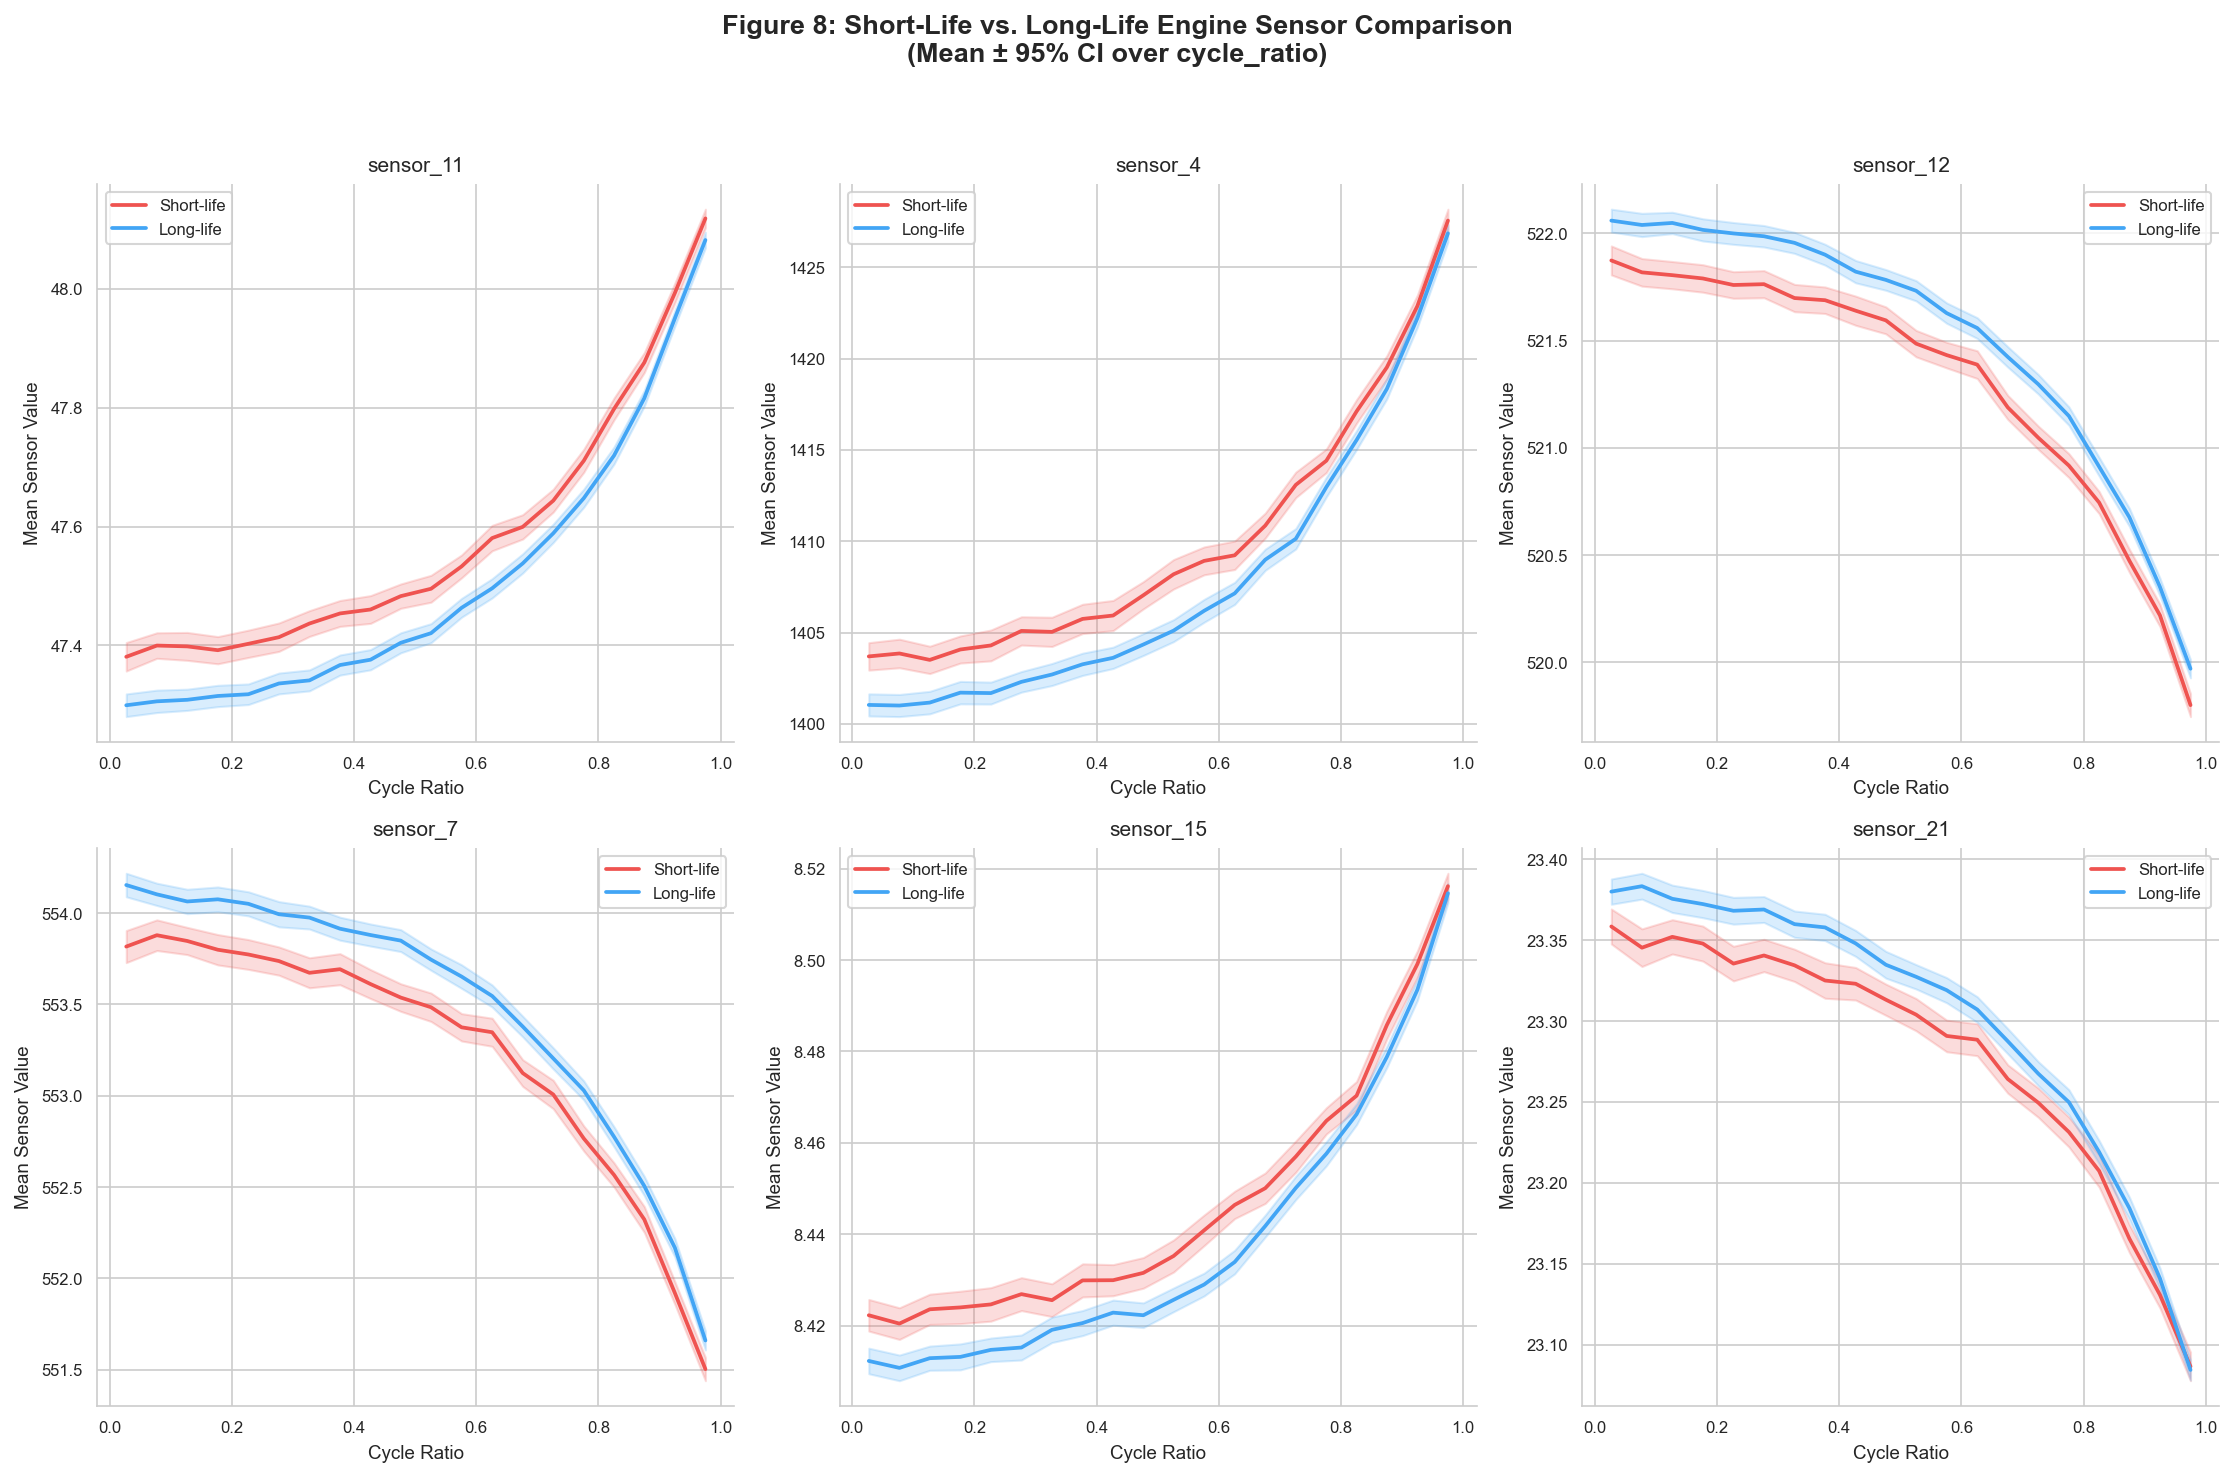

Saved: ../figures\Figure_08_short_vs_long_life_engines.png


In [19]:
# Define short-life (bottom 25%) and long-life (top 25%) engine groups
q25 = engine_summary['max_cycle'].quantile(0.25)
q75 = engine_summary['max_cycle'].quantile(0.75)
short_ids = engine_summary[engine_summary['max_cycle'] <= q25]['unit_number'].tolist()
long_ids  = engine_summary[engine_summary['max_cycle'] >= q75]['unit_number'].tolist()

df_short = df[df['unit_number'].isin(short_ids)].copy()
df_long  = df[df['unit_number'].isin(long_ids)].copy()

print(f'Short-life engines (≤ {q25:.0f} cycles): {len(short_ids)} engines')
print(f'Long-life  engines (≥ {q75:.0f} cycles): {len(long_ids)} engines')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Figure 8: Short-Life vs. Long-Life Engine Sensor Comparison\n(Mean ± 95% CI over cycle_ratio)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for idx, sensor in enumerate(informative_sensors):
    ax = axes[idx]

    for grp_df, label, color in [(df_short, 'Short-life', '#EF5350'), (df_long, 'Long-life', '#42A5F5')]:
        bin_stats = grp_df.groupby('cr_bin', observed=True)[sensor].agg(['mean', 'std', 'count'])
        bin_stats['ci95'] = 1.96 * bin_stats['std'] / np.sqrt(bin_stats['count'])
        xvals = [iv.mid for iv in bin_stats.index]
        ax.plot(xvals, bin_stats['mean'], color=color, linewidth=1.8, label=label)
        ax.fill_between(xvals,
                        bin_stats['mean'] - bin_stats['ci95'],
                        bin_stats['mean'] + bin_stats['ci95'],
                        alpha=0.2, color=color)

    ax.set_xlabel('Cycle Ratio', fontsize=9)
    ax.set_ylabel('Mean Sensor Value', fontsize=9)
    ax.set_title(sensor, fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = os.path.join(FIGURES_DIR, 'Figure_08_short_vs_long_life_engines.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 14: Figure 9 — Correlation Heatmap

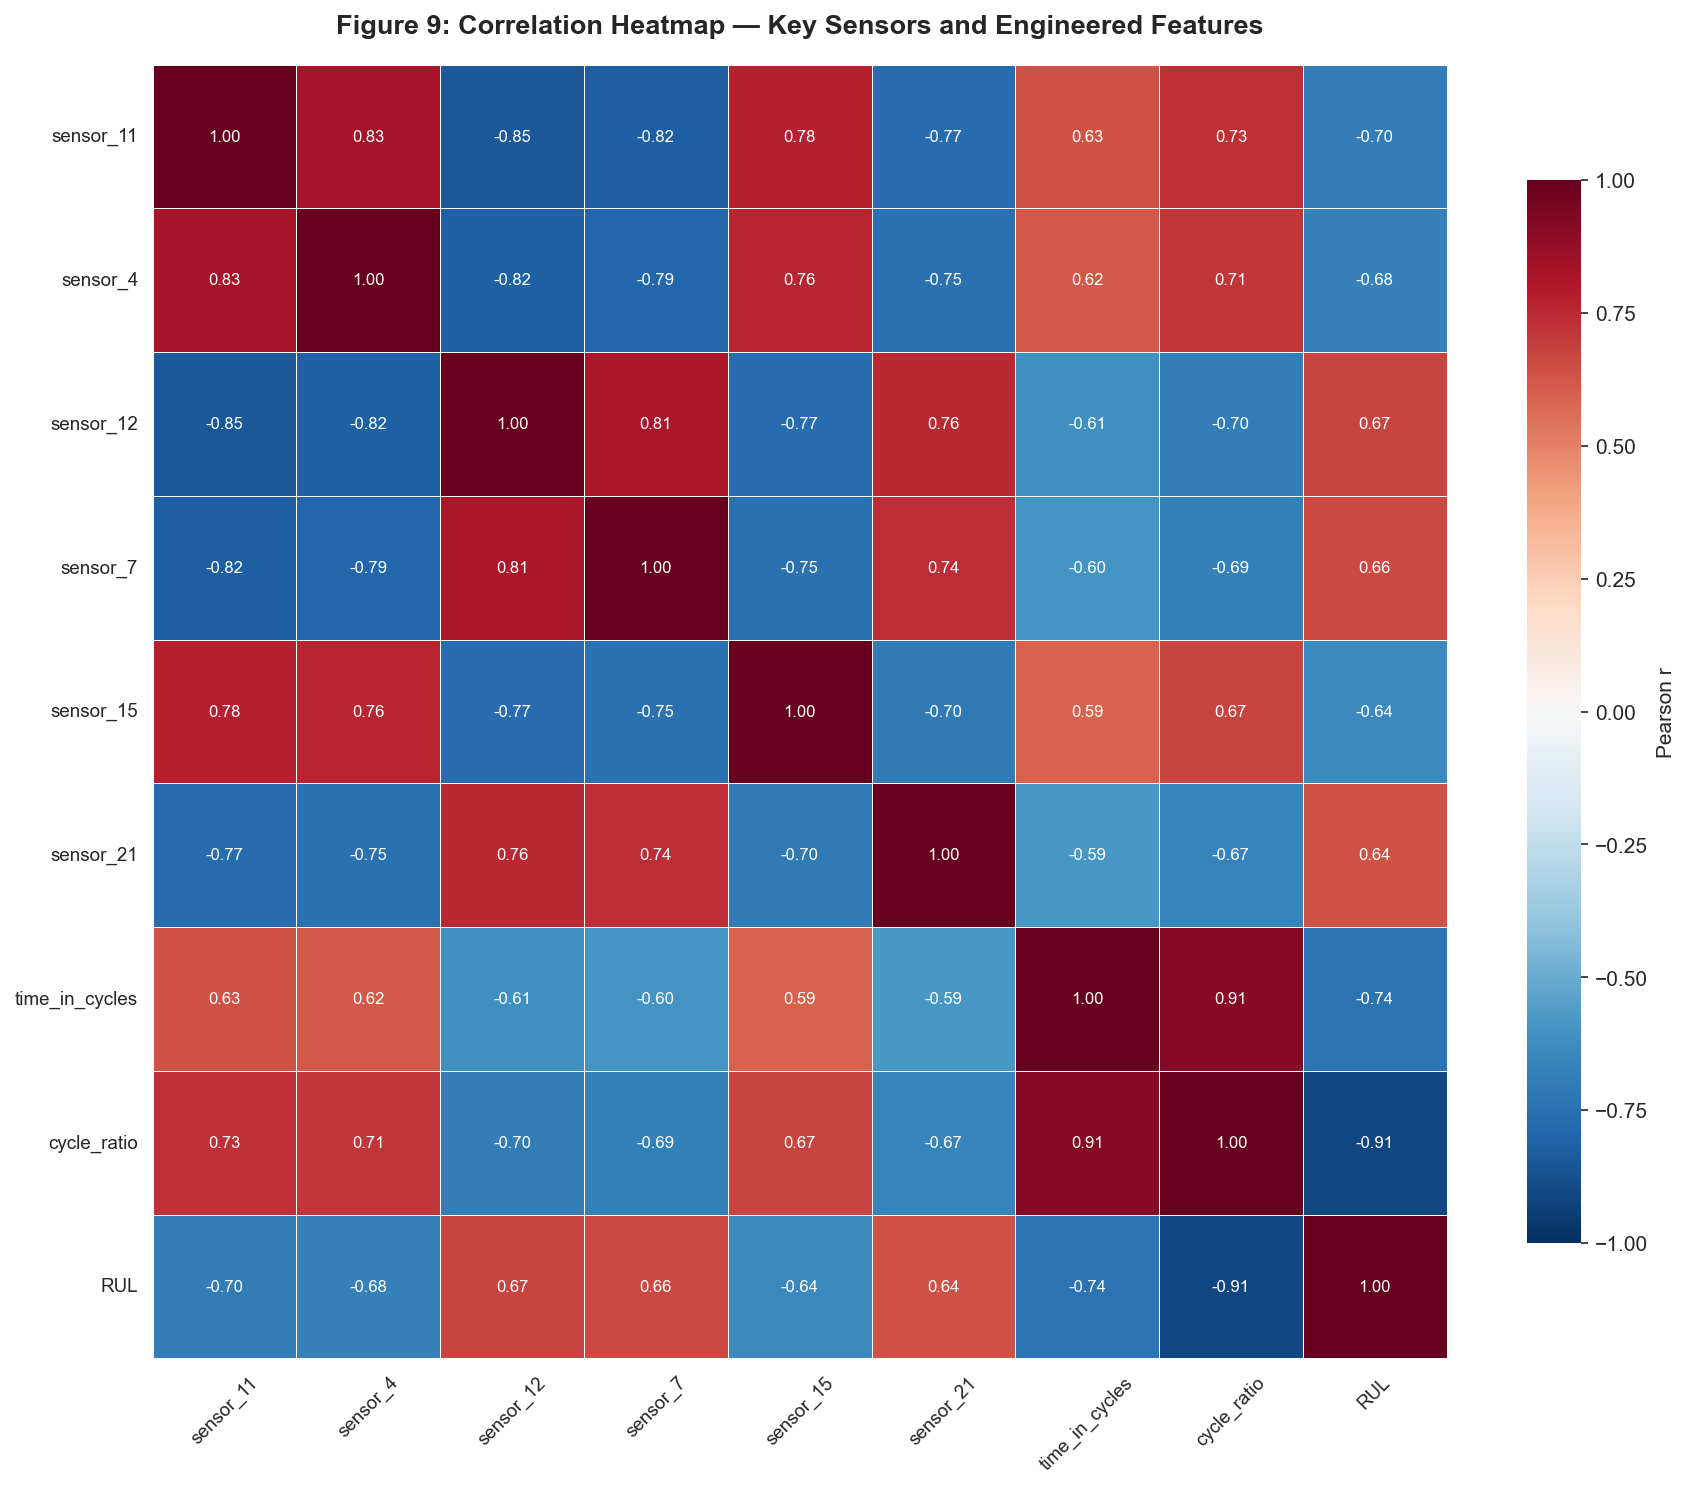

Saved: ../figures\Figure_09_correlation_heatmap.png


In [20]:
# Select informative sensors + key engineered features for heatmap
heatmap_features = informative_sensors + ['time_in_cycles', 'cycle_ratio', 'RUL']

corr_matrix = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    annot_kws={'size': 8},
)

ax.set_title('Figure 9: Correlation Heatmap — Key Sensors and Engineered Features',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'Figure_09_correlation_heatmap.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 15: Figure 10 — PCA Life-Stage Visualization

PCA input sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2', 'sensor_17', 'sensor_3']
Explained variance: PC1=74.7%, PC2=4.2%, PC3=3.8%
Cumulative (PC1+PC2): 78.8%


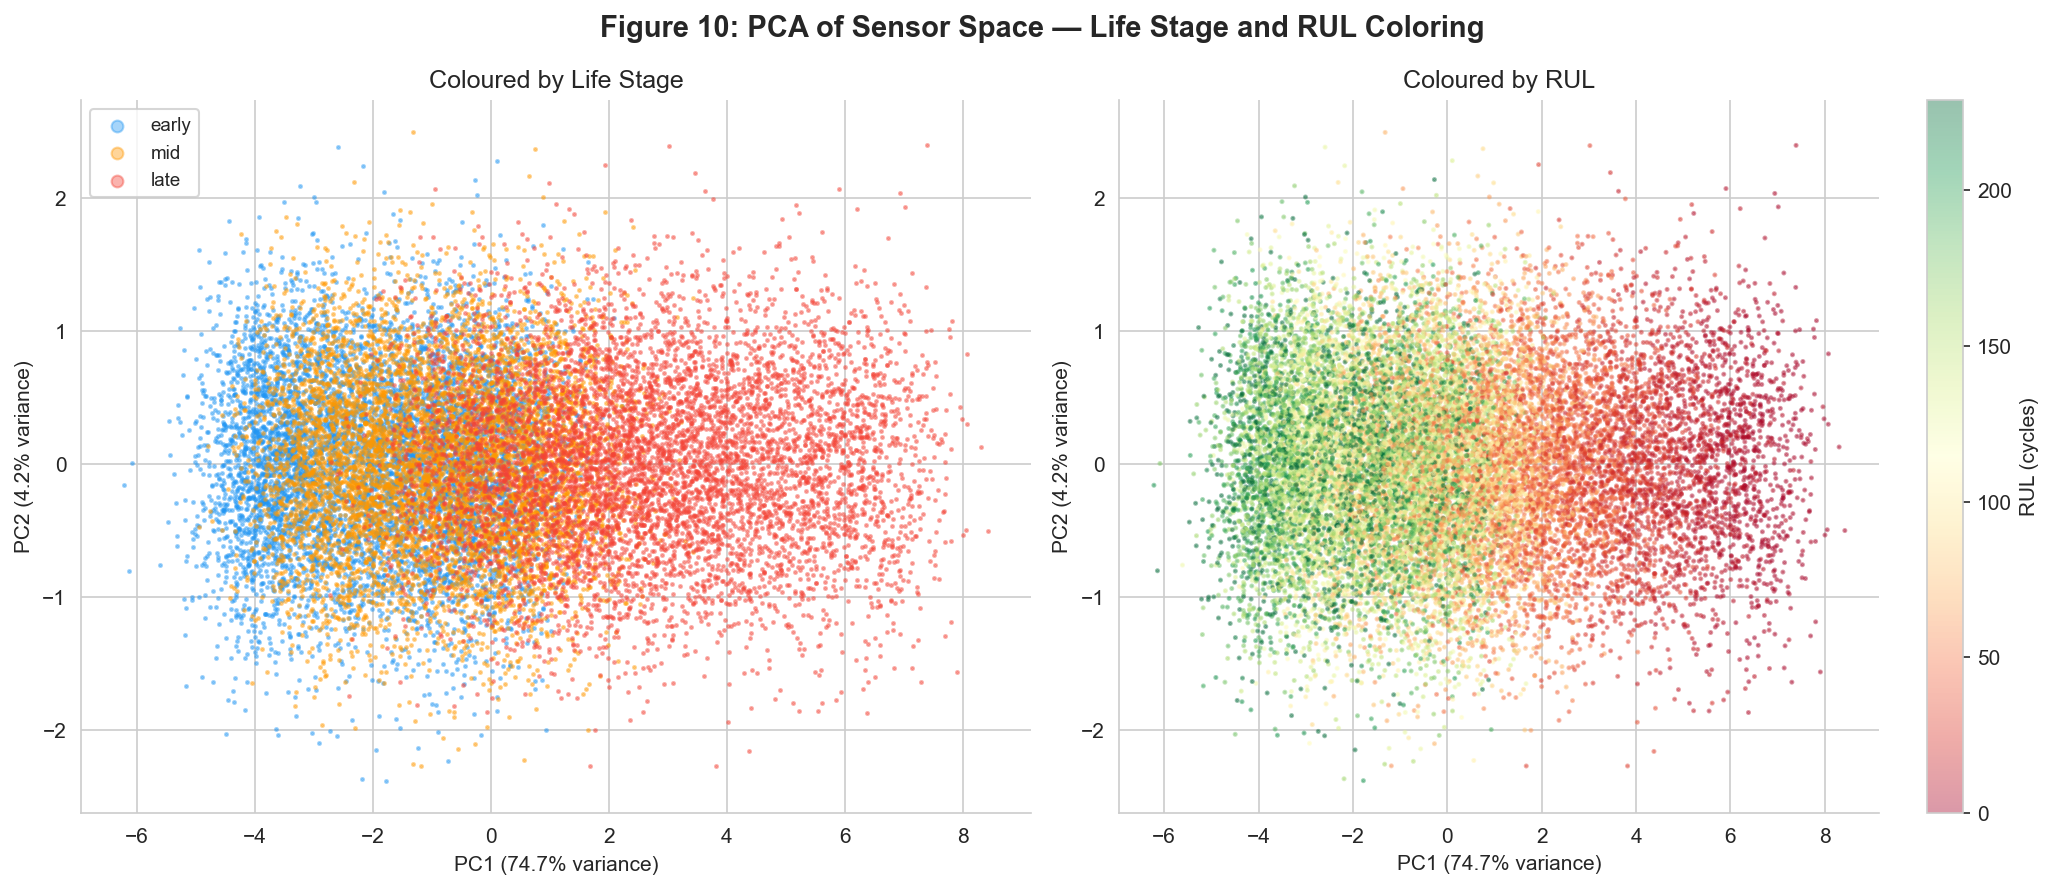

Saved: ../figures\Figure_10_pca_life_stage.png


In [21]:
# PCA on standardised informative sensors
pca_sensors = sensor_screen[~sensor_screen['low_variance']]['sensor'].head(10).tolist()
print(f'PCA input sensors: {pca_sensors}')

df_pca_input = df[pca_sensors].dropna()
idx_pca = df_pca_input.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_input)

pca = PCA(n_components=3)
pcs = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pcs, columns=['PC1', 'PC2', 'PC3'], index=idx_pca)
df_pca['life_stage'] = df.loc[idx_pca, 'life_stage']
df_pca['RUL']        = df.loc[idx_pca, 'RUL']

explained = pca.explained_variance_ratio_ * 100
print(f'Explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, PC3={explained[2]:.1f}%')
print(f'Cumulative (PC1+PC2): {sum(explained[:2]):.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 10: PCA of Sensor Space — Life Stage and RUL Coloring',
             fontsize=14, fontweight='bold')

# Left: Colored by life stage
ax = axes[0]
for stage in ['early', 'mid', 'late']:
    mask = df_pca['life_stage'] == stage
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               c=LIFE_COLORS[stage], s=2, alpha=0.4, label=stage)
ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=10)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=10)
ax.set_title('Coloured by Life Stage')
ax.legend(markerscale=4, fontsize=9)

# Right: Colored by RUL (continuous)
ax2 = axes[1]
sc = ax2.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['RUL'],
                 cmap='RdYlGn', s=2, alpha=0.4, vmin=0, vmax=df_pca['RUL'].quantile(0.95))
plt.colorbar(sc, ax=ax2, label='RUL (cycles)')
ax2.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=10)
ax2.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=10)
ax2.set_title('Coloured by RUL')

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'Figure_10_pca_life_stage.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {fig_path}')

## Section 16: Save Cleaned Dataset and Summary Tables

In [22]:
# Drop the temporary bin column before saving
df_clean = df.drop(columns=['cr_bin'], errors='ignore')

cleaned_path = os.path.join(PROCESSED_DIR, 'SmartFactory_cleaned.csv')
df_clean.to_csv(cleaned_path, index=False)

print(f'Cleaned dataset saved: {cleaned_path}')
print(f'Shape: {df_clean.shape}')
print(f'Columns: {list(df_clean.columns)}')

Cleaned dataset saved: ../data/processed\SmartFactory_cleaned.csv
Shape: (20631, 42)
Columns: ['unit_number', 'time_in_cycles', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'max_cycle', 'RUL', 'cycle_ratio', 'life_stage', 'near_failure', 'capped_RUL', 'sensor_11_roll20', 'sensor_4_roll20', 'sensor_12_roll20', 'sensor_7_roll20', 'sensor_15_roll20', 'sensor_21_roll20', 'sensor_20_roll20', 'sensor_2_roll20', 'sensor_17_roll20', 'sensor_3_roll20']


In [23]:
# Engine-level summary
engine_level = df.groupby('unit_number').agg(
    max_cycle=('max_cycle', 'first'),
    total_rows=('time_in_cycles', 'count'),
    near_failure_rows=('near_failure', 'sum'),
    near_failure_pct=('near_failure', 'mean'),
).reset_index()
engine_level['near_failure_pct'] = (engine_level['near_failure_pct'] * 100).round(1)

# Add mean sensor values per engine for top sensors
engine_sensor_means = df.groupby('unit_number')[informative_sensors].mean().reset_index()
engine_level = engine_level.merge(engine_sensor_means, on='unit_number')

engine_level.to_csv(os.path.join(OUTPUTS_DIR, 'engine_level_summary.csv'), index=False)
print('Engine-level summary saved.')
print(engine_level.head(10).to_string(index=False))

Engine-level summary saved.
 unit_number  max_cycle  total_rows  near_failure_rows  near_failure_pct  sensor_11    sensor_4  sensor_12   sensor_7  sensor_15  sensor_21
           1        192         192                 31              16.1  47.514063 1407.262135 521.459427 553.439427   8.436555  23.306310
           2        287         287                 31              10.8  47.389512 1404.265854 521.811603 553.853484   8.423983  23.338997
           3        179         179                 31              17.3  47.427039 1405.628994 521.773966 553.800056   8.430236  23.321931
           4        189         189                 31              16.4  47.515132 1408.253915 521.501005 553.443016   8.439303  23.294502
           5        269         269                 31              11.5  47.402268 1404.878439 521.866431 553.882342   8.425968  23.336284
           6        188         188                 31              16.5  47.710372 1413.876117 520.925798 552.790532   8.458306  23

In [24]:
# Feature summary table
all_features = COLUMNS + ['max_cycle', 'RUL', 'cycle_ratio', 'life_stage',
                           'near_failure', 'capped_RUL'] + roll_cols
feature_descriptions = {
    'unit_number':           'Engine identifier (1–100 in FD001)',
    'time_in_cycles':        'Operational cycle index (1 = first cycle recorded)',
    'operational_setting_1': 'Flight condition parameter 1',
    'operational_setting_2': 'Flight condition parameter 2',
    'operational_setting_3': 'Flight condition parameter 3',
    'max_cycle':             'Total engine lifetime (cycles to failure)',
    'RUL':                   'Remaining Useful Life = max_cycle - time_in_cycles',
    'cycle_ratio':           'Normalised lifecycle position = time_in_cycles / max_cycle',
    'life_stage':            'Lifecycle stage: early (≤0.33), mid (0.33–0.67), late (>0.67)',
    'near_failure':          'Binary flag: 1 if RUL ≤ 30 cycles (EDA risk band indicator)',
    'capped_RUL':            'RUL capped at 125 — for Assignment 2 modeling stability only',
}
for s in SENSOR_COLS:
    feature_descriptions[s] = f'IoT sensor channel {s} (anonymised — physical unit unknown)'
for s in top_sensors:
    k = f'{s}_roll{ROLL_WINDOW}'
    feature_descriptions[k] = f'{ROLL_WINDOW}-cycle rolling mean of {s}, computed per engine'

feat_df = pd.DataFrame([
    {'feature': f, 'description': feature_descriptions.get(f, ''), 'dtype': str(df_clean[f].dtype) if f in df_clean.columns else 'N/A'}
    for f in df_clean.columns
])
feat_df.to_csv(os.path.join(OUTPUTS_DIR, 'feature_summary.csv'), index=False)
print('Feature summary saved.')
print(feat_df.to_string(index=False))

Feature summary saved.
              feature                                                       description    dtype
          unit_number                                Engine identifier (1–100 in FD001)    int64
       time_in_cycles                Operational cycle index (1 = first cycle recorded)    int64
operational_setting_1                                      Flight condition parameter 1  float64
operational_setting_2                                      Flight condition parameter 2  float64
operational_setting_3                                      Flight condition parameter 3  float64
             sensor_1  IoT sensor channel sensor_1 (anonymised — physical unit unknown)  float64
             sensor_2  IoT sensor channel sensor_2 (anonymised — physical unit unknown)  float64
             sensor_3  IoT sensor channel sensor_3 (anonymised — physical unit unknown)  float64
             sensor_4  IoT sensor channel sensor_4 (anonymised — physical unit unknown)  float64
       

## Section 17: Key Findings and Recommendations Summary

In [25]:
# Compute key statistics for findings
n_engines       = df['unit_number'].nunique()
mean_lifetime   = engine_summary['max_cycle'].mean()
min_lifetime    = engine_summary['max_cycle'].min()
max_lifetime    = engine_summary['max_cycle'].max()
nf_pct          = df['near_failure'].mean() * 100
n_low_var       = len(low_var_sensors)
top_sensor_name = sensor_screen[~sensor_screen['low_variance']]['sensor'].iloc[0]
top_corr        = sensor_screen[~sensor_screen['low_variance']]['abs_corr_with_RUL'].iloc[0]
top_6_str       = ', '.join(informative_sensors)
pca_var_2       = sum(pca.explained_variance_ratio_[:2]) * 100

print('=== Key Statistics for Report Findings ===')
print(f'Engines analysed          : {n_engines}')
print(f'Mean engine lifetime      : {mean_lifetime:.1f} cycles')
print(f'Lifetime range            : {min_lifetime} – {max_lifetime} cycles')
print(f'Near-failure rows         : {nf_pct:.1f}%')
print(f'Near-constant sensors     : {n_low_var} (sensors: {low_var_sensors})')
print(f'Top RUL-correlated sensor : {top_sensor_name} (|r| = {top_corr:.3f})')
print(f'Top 6 informative sensors : {top_6_str}')
print(f'PCA PC1+PC2 variance      : {pca_var_2:.1f}%')

=== Key Statistics for Report Findings ===
Engines analysed          : 100
Mean engine lifetime      : 206.3 cycles
Lifetime range            : 128 – 362 cycles
Near-failure rows         : 15.0%
Near-constant sensors     : 7 (sensors: ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6'])
Top RUL-correlated sensor : sensor_11 (|r| = 0.696)
Top 6 informative sensors : sensor_11, sensor_4, sensor_12, sensor_7, sensor_15, sensor_21
PCA PC1+PC2 variance      : 78.8%


In [26]:
# Save key findings table (structured)
findings = pd.DataFrame([
    {
        'finding_id': 'F1',
        'title': 'Significant Engine Lifetime Variability',
        'observation': f'Engine lifetimes range from {min_lifetime} to {max_lifetime} cycles with a mean of {mean_lifetime:.0f} cycles.',
        'evidence': 'Figure 2; engine_level_summary.csv',
        'business_implication': 'High variability makes fixed-interval maintenance wasteful for short-life engines and potentially unsafe for long-life engines near their limit.'
    },
    {
        'finding_id': 'F2',
        'title': 'Near-Failure Rows Represent a Minority of Operating Time',
        'observation': f'{nf_pct:.1f}% of all sensor readings correspond to the near-failure window (RUL ≤ 30 cycles).',
        'evidence': 'Figure 3; RUL calculation in Section 4',
        'business_implication': 'Engines spend most of their life in the healthy or degrading-but-not-critical state. Early degradation detection is therefore achievable with sensor data before the critical window is reached.'
    },
    {
        'finding_id': 'F3',
        'title': f'{n_low_var} Sensor Channels Are Near-Constant and Carry Low Diagnostic Information',
        'observation': f'Sensors {low_var_sensors} show near-zero variance across all cycles and engines.',
        'evidence': 'Figure 1; sensor standard deviation table',
        'business_implication': 'These channels can be deprioritised in a real-time monitoring dashboard to reduce data transmission overhead and model complexity.'
    },
    {
        'finding_id': 'F4',
        'title': f'A Subset of Sensors Strongly Correlates with Remaining Useful Life',
        'observation': f'The highest |correlation with RUL| is achieved by {top_sensor_name} (|r| = {top_corr:.3f}). The top 6 informative sensors are: {top_6_str}.',
        'evidence': 'Figure 5; sensor_rul_correlation.csv',
        'business_implication': 'These sensors are the most promising predictors for a future RUL regression model and should be prioritised in real-time condition monitoring.'
    },
    {
        'finding_id': 'F5',
        'title': 'Key Sensors Show Monotonic Degradation Trends with Lifecycle Progression',
        'observation': f'Top informative sensors exhibit clear directional shifts across lifecycle stages (early → mid → late), as confirmed by life-stage boxplots and trend plots.',
        'evidence': 'Figures 6 and 7; sensor_life_stage_shift.csv',
        'business_implication': 'Monotonic sensor trends provide detectable early-warning signals that can trigger predictive maintenance alerts before the near-failure window.'
    },
    {
        'finding_id': 'F6',
        'title': 'Short-Life and Long-Life Engines Show Distinguishable Sensor Profiles',
        'observation': 'When grouped by lifetime quartile, short-life and long-life engines show measurable differences in mean sensor trajectories across the normalised lifecycle.',
        'evidence': 'Figure 8; engine_level_summary.csv',
        'business_implication': 'Engine-level sensor history may allow early identification of higher-risk units, supporting prioritised inspection before failure.'
    },
    {
        'finding_id': 'F7',
        'title': f'PCA Reveals Structured Sensor Space Aligned with Lifecycle Stage',
        'observation': f'The first two principal components capture {pca_var_2:.1f}% of variance in the informative sensor subspace. Life stage groups separate progressively along PC1.',
        'evidence': 'Figure 10; PCA analysis in Section 15',
        'business_implication': 'A compact latent representation of sensor state aligns with engine health stage, suggesting that dimensionality reduction can simplify future predictive modeling without large information loss.'
    },
])

findings.to_csv(os.path.join(OUTPUTS_DIR, 'key_findings_table.csv'), index=False)
print('Key findings table saved.')
print(findings[['finding_id', 'title']].to_string(index=False))

Key findings table saved.
finding_id                                                                    title
        F1                                  Significant Engine Lifetime Variability
        F2                 Near-Failure Rows Represent a Minority of Operating Time
        F3 7 Sensor Channels Are Near-Constant and Carry Low Diagnostic Information
        F4       A Subset of Sensors Strongly Correlates with Remaining Useful Life
        F5 Key Sensors Show Monotonic Degradation Trends with Lifecycle Progression
        F6    Short-Life and Long-Life Engines Show Distinguishable Sensor Profiles
        F7         PCA Reveals Structured Sensor Space Aligned with Lifecycle Stage


In [27]:
# Save recommendations table
recommendations = pd.DataFrame([
    {
        'rec_id': 'R1',
        'title': 'Implement Condition-Based Maintenance Monitoring for Key Sensor Channels',
        'action': f'Deploy real-time monitoring dashboards for the top informative sensor channels ({top_6_str}), using rolling averages and trend alerts.',
        'supporting_evidence': 'Figure 5 (sensor-RUL correlation ranking); Figure 6 (sensor trends over lifecycle)',
        'expected_impact': 'Earlier detection of degradation onset; reduced reliance on fixed-interval inspection schedules.',
        'implementation_ease': 'Medium — requires dashboard integration with existing IoT sensor pipeline.',
        'priority': 'High'
    },
    {
        'rec_id': 'R2',
        'title': 'Use Near-Failure Risk Band for Maintenance Prioritisation',
        'action': f'Flag any engine whose sensor trend model predicts RUL ≤ 30 cycles as high-priority for inspection. ({nf_pct:.1f}% of current operating time falls in this band.)',
        'supporting_evidence': 'Figure 3 (near-failure distribution); near_failure feature in cleaned dataset',
        'expected_impact': 'Structured triage of maintenance resources — high-risk engines receive immediate attention, low-risk engines are deferred.',
        'implementation_ease': 'Low — the risk band is directly derivable from sensor trend analysis.',
        'priority': 'High'
    },
    {
        'rec_id': 'R3',
        'title': 'Deprioritise Near-Constant Sensor Channels in Monitoring Infrastructure',
        'action': f'Reduce data collection frequency or exclude {n_low_var} near-constant sensor channels ({low_var_sensors}) from the live monitoring pipeline.',
        'supporting_evidence': 'Figure 1 (sensor variance analysis); data_quality_summary.csv',
        'expected_impact': 'Reduced data transmission cost and computational load with negligible loss of diagnostic signal.',
        'implementation_ease': 'Low — configuration change in data ingestion pipeline.',
        'priority': 'Medium'
    },
    {
        'rec_id': 'R4',
        'title': 'Develop Engine-Aware RUL Prediction Model for Assignment 2',
        'action': 'Train a regression model (e.g. Random Forest or Gradient Boosting) on time_in_cycles, cycle_ratio, top sensor channels, and rolling means. Use engine-aware cross-validation (hold out complete engines).',
        'supporting_evidence': 'EDA findings F4–F5; Figure 9 (correlation heatmap showing feature relationships)',
        'expected_impact': 'Operational: provide maintenance teams with an estimated RUL per engine, enabling proactive scheduling.',
        'implementation_ease': 'Medium — requires model training and validation infrastructure.',
        'priority': 'High (Assignment 2 deliverable)'
    },
    {
        'rec_id': 'R5',
        'title': 'Investigate High-Variability Engines for Maintenance Pattern Anomalies',
        'action': f'Conduct targeted review of engines with unusually short lifetimes (< {min_lifetime + 20} cycles) and those with atypical sensor profiles.',
        'supporting_evidence': 'Figure 8 (short vs long life comparison); engine_level_summary.csv',
        'expected_impact': 'Operational insight: identify whether short-life outliers reflect manufacturing variation, maintenance history differences, or operating condition differences.',
        'implementation_ease': 'Low — requires cross-referencing sensor data with maintenance records.',
        'priority': 'Medium'
    },
])

recommendations.to_csv(os.path.join(OUTPUTS_DIR, 'recommendations_table.csv'), index=False)
print('Recommendations table saved.')
print(recommendations[['rec_id', 'title', 'priority']].to_string(index=False))

Recommendations table saved.
rec_id                                                                    title                        priority
    R1 Implement Condition-Based Maintenance Monitoring for Key Sensor Channels                            High
    R2                Use Near-Failure Risk Band for Maintenance Prioritisation                            High
    R3  Deprioritise Near-Constant Sensor Channels in Monitoring Infrastructure                          Medium
    R4               Develop Engine-Aware RUL Prediction Model for Assignment 2 High (Assignment 2 deliverable)
    R5   Investigate High-Variability Engines for Maintenance Pattern Anomalies                          Medium


In [28]:
# Final pipeline summary
print('=' * 65)
print('PIPELINE COMPLETE — SUMMARY OF OUTPUTS')
print('=' * 65)
print(f'Cleaned dataset   : data/processed/SmartFactory_cleaned.csv')
print(f'  Shape           : {df_clean.shape}')
print(f'  Engines         : {df_clean["unit_number"].nunique()}')
print(f'  Columns         : {df_clean.shape[1]}')
print()
print('Figures saved:')
for f in sorted(os.listdir(FIGURES_DIR)):
    print(f'  {f}')
print()
print('Output tables saved:')
for f in sorted(os.listdir(OUTPUTS_DIR)):
    if f.endswith('.csv'):
        print(f'  {f}')
print()
print('Next step: review figures and report draft, then update')
print('reports/Assignment1_SmartFactory_Report.md with actual values.')

PIPELINE COMPLETE — SUMMARY OF OUTPUTS
Cleaned dataset   : data/processed/SmartFactory_cleaned.csv
  Shape           : (20631, 42)
  Engines         : 100
  Columns         : 42

Figures saved:
  Figure_01_data_quality_missingness.png
  Figure_02_engine_lifetime_distribution.png
  Figure_03_rul_distribution.png
  Figure_04_engine_lifecycle_examples.png
  Figure_05_sensor_rul_correlation.png
  Figure_06_key_sensor_trends.png
  Figure_07_life_stage_sensor_boxplots.png
  Figure_08_short_vs_long_life_engines.png
  Figure_09_correlation_heatmap.png
  Figure_10_pca_life_stage.png

Output tables saved:
  data_quality_summary.csv
  engine_level_summary.csv
  feature_summary.csv
  key_findings_table.csv
  recommendations_table.csv
  sensor_life_stage_shift.csv
  sensor_rul_correlation.csv

Next step: review figures and report draft, then update
reports/Assignment1_SmartFactory_Report.md with actual values.
